In [1]:
# Load the Drive helper and mount
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install numpy==1.26.0
!pip install -q rasterio geopandas contextily
!apt install gdal-bin
!pip install fiona
!pip install patchify
!pip install scikit-image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 83.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 54.5 MB/s eta 0:00:00
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  python3-gdal python3-numpy
Suggested packages:
  libgdal-grass python-numpy-doc python3-pytest
The following NEW packages will be installed:
  gdal-bin python3-gdal python3-numpy
0 upgraded, 3 new

In [3]:
!pip install --upgrade pandas
!pip install --upgrade numpy
!pip install --upgrade --force-reinstall pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 60.1 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 35.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.0
    Uninstalling numpy-1.26.0:
      Successfully uninstalled numpy-1.26.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This 

In [1]:

# Import libraries
import sys
sys.path.append('/content/drive/MyDrive/landslide/Codes') # Please put the path accordingly where you have stored the data

import os
import fiona
import numpy as np
import cv2
import rasterio
from rasterio import plot
from rasterio.plot import reshape_as_image
import rasterio.mask
from rasterio.mask import mask
#from rasterio.features import rasterize
import pandas as pd
import geopandas as gpd
from osgeo import gdal
from shapely.geometry import box
from shapely.geometry import mapping, Point, Polygon,MultiPolygon
from shapely.ops import unary_union
from glob import glob
from matplotlib import pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import random


In [2]:
from rasterio.features import rasterize

In [ ]:
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400

In [3]:
def generate_mask(raster_path, shape_path, output_path, file_name):

    """Function that generates a binary mask from a vector file (shp or geojson)

    raster_path = path to the .tif;

    shape_path = path to the shapefile or GeoJson.

    output_path = Path to save the binary mask.

    file_name = Name of the file.

    """

    #load raster

    with rasterio.open(raster_path, "r") as src:
        raster_img = src.read()
        raster_meta = src.meta

    #load o shapefile ou GeoJson
    train_df = gpd.read_file(shape_path)

    #Verify crs
    if train_df.crs != src.crs:
        print(" Raster crs : {}, Vector crs : {}.\n Convert vector and raster to the same CRS.".format(src.crs,train_df.crs))


    #Function that generates the mask
    def poly_from_utm(polygon, transform):
        poly_pts = []

        poly = unary_union(polygon)
        for i in np.array(poly.exterior.coords):

            poly_pts.append(~transform * tuple(i))

        new_poly = Polygon(poly_pts)
        return new_poly


    poly_shp = []
    im_size = (src.meta['height'], src.meta['width'])
    for num, row in train_df.iterrows():
        if row['geometry'].geom_type == 'Polygon':
            poly = poly_from_utm(row['geometry'], src.meta['transform'])
            poly_shp.append(poly)
        else:
            liste = []
            for polygon in row['geometry'].geoms:
                liste.append(polygon)
                for p in liste:
                  poly = poly_from_utm(p, src.meta['transform'])
                  poly_shp.append(poly)

    mask = rasterize(shapes=poly_shp,
                     out_shape=im_size)

    #Salve
    mask = mask.astype("uint16")

    bin_mask_meta = src.meta.copy()
    bin_mask_meta.update({'count': 1})
    os.chdir(output_path)
    with rasterio.open(file_name, 'w', **bin_mask_meta) as dst:
        dst.write(mask * 255, 1)

In [ ]:
"""
#TO USE IF THE CELL ABOVE DOESNT WORK
def generate_mask(raster_path, shape_path, output_path, file_name):

    Function that generates a binary mask from a vector file (shp or geojson)

    raster_path = path to the .tif;

    shape_path = path to the shapefile or GeoJson.

    output_path = Path to save the binary mask.

    file_name = Name of the file.



    #load raster

    with rasterio.open(raster_path, "r") as src:
        raster_img = src.read()
        raster_meta = src.meta

    #load o shapefile ou GeoJson
    train_df = gpd.read_file(shape_path)

    #Verify crs
    if train_df.crs != src.crs:
        train_df = train_df.to_crs(src.crs)
        print(" Raster crs : {}, Vector crs : {}.\n Convert vector and raster to the same CRS.".format(src.crs,train_df.crs))


    #Function that generates the mask
    def poly_from_utm(polygon, transform):
        poly_pts = []
        poly = unary_union(polygon)
        for coords in np.array(poly.exterior.coords):
            x, y = coords[:2]  # Extract only the first two values (x, y)
            col, row = ~transform * (x, y)
            poly_pts.append((col, row))

        new_poly = Polygon(poly_pts)  # Create a new polygon
        return new_poly


    poly_shp = []
    im_size = (src.meta['height'], src.meta['width'])
    for num, row in train_df.iterrows():
        if row['geometry'].geom_type == 'Polygon':
            poly = poly_from_utm(row['geometry'], src.meta['transform'])
            poly_shp.append(poly)
        else:
            liste = []
            for polygon in row['geometry'].geoms:
                liste.append(polygon)
                for p in liste:
                  poly = poly_from_utm(p, src.meta['transform'])
                  poly_shp.append(poly)

    mask = rasterize(shapes=poly_shp,
                     out_shape=im_size)

    #Salve
    mask = mask.astype("uint16")

    bin_mask_meta = src.meta.copy()
    bin_mask_meta.update({'count': 1})
    os.chdir(output_path)
    with rasterio.open(file_name, 'w', **bin_mask_meta) as dst:
        dst.write(mask * 255, 1)
"""

In [ ]:
# You need to use the following parameters in the generate_mask function:

# Path where the study_area.tif raster is located
raster_path ="/content/drive/MyDrive/landslide/Data/Test_data/Post/Masara_post.tif"

# Path where the train_landslide.shp is located
shape_path = "/content/drive/MyDrive/landslide/Data/Change_Shapes/Masara.shp"

# Path to save the output file
output_path ="/content/drive/MyDrive/landslide/Data/Test_data/Change_Masks"

# Output file name
file_name ="Masara.tif" # Put a name here as to how you want to save the file.

# Run the function for the training masks
generate_mask(raster_path=raster_path, shape_path=shape_path,
             output_path=output_path, file_name=file_name)

In [ ]:
# You need to use the following parameters in the generate_mask function:

# Path where the study_area.tif raster is located
raster_path ="/content/drive/MyDrive/landslide/Data/Test_data/Post/Masara_post.tif"

# Path where the train_landslide.shp is located
shape_path = "/content/drive/MyDrive/landslide/Data/Inventories/Masara.shp"

# Path to save the output file
output_path ="/content/drive/MyDrive/landslide/Data/Test_data/Masks"

# Output file name
file_name ="Masara.tif" # Put a name here as to how you want to save the file.

# Run the function for the training masks
generate_mask(raster_path=raster_path, shape_path=shape_path,
             output_path=output_path, file_name=file_name)

In [ ]:
# You need to use the following parameters in the generate_mask function:

# Path where the study_area.tif raster is located
raster_path ="/content/drive/MyDrive/landslide/Data/Test_data/Post/Mesetas_post.tif"

# Path where the train_landslide.shp is located
shape_path = "/content/drive/MyDrive/landslide/Data/Change_Shapes/Mesestas.shp"

# Path to save the output file
output_path ="/content/drive/MyDrive/landslide/Data/Test_data/Change_Masks"

# Output file name
file_name ="Mesetas.tif" # Put a name here as to how you want to save the file.

# Run the function for the training masks
generate_mask(raster_path=raster_path, shape_path=shape_path,
             output_path=output_path, file_name=file_name)

AttributeError: Can't pickle local object 'generate_mask_optimized_cpu.<locals>.poly_from_utm'

In [ ]:
# You need to use the following parameters in the generate_mask function:

# Path where the study_area.tif raster is located
raster_path ="/content/drive/MyDrive/landslide/Data/Test_data/Post/Mesetas_post.tif"

# Path where the train_landslide.shp is located
shape_path = "/content/drive/MyDrive/landslide/Data/Inventories/Mesestas.shp"

# Path to save the output file
output_path ="/content/drive/MyDrive/landslide/Data/Test_data/Masks"

# Output file name
file_name ="Mesetas.tif" # Put a name here as to how you want to save the file.

# Run the function for the training masks
generate_mask(raster_path=raster_path, shape_path=shape_path,
             output_path=output_path, file_name=file_name)

In [ ]:
# You need to use the following parameters in the generate_mask function:

# Path where the study_area.tif raster is located
raster_path ="/content/drive/MyDrive/landslide/Data/Test_data/Post/Uganda_post.tif"

# Path where the train_landslide.shp is located
shape_path = "/content/drive/MyDrive/landslide/Data/Change_Shapes/Uganda.shp"

# Path to save the output file
output_path ="/content/drive/MyDrive/landslide/Data/Test_data/Change_Masks"

# Output file name
file_name ="Uganda.tif" # Put a name here as to how you want to save the file.

# Run the function for the training masks
generate_mask(raster_path=raster_path, shape_path=shape_path,
             output_path=output_path, file_name=file_name)

CuPy version: 13.4.1
GPU operation failed: CuPy failed to load libnvrtc.so.11.2: OSError: libnvrtc.so.11.2: cannot open shared object file: No such file or directory, falling back to CPU


In [ ]:
# You need to use the following parameters in the generate_mask function:

# Path where the study_area.tif raster is located
raster_path ="/content/drive/MyDrive/landslide/Data/Test_data/Post/HpaAn_post.tif"

# Path where the train_landslide.shp is located
shape_path = "/content/drive/MyDrive/landslide/Data/Inventories/HpaAn.shp"

# Path to save the output file
output_path ="/content/drive/MyDrive/landslide/Data/Test_data/Masks"

# Output file name
file_name ="HpaAn.tif" # Put a name here as to how you want to save the file.

# Run the function for the training masks
generate_mask(raster_path=raster_path, shape_path=shape_path,
             output_path=output_path, file_name=file_name)

In [4]:
def readdata(directory, folder_name):

    data_path = os.path.join(directory, folder_name)
    data_list = {}

    for f in sorted(os.listdir(data_path)):
        fdir = os.path.join(data_path, f)
        _, ext = os.path.splitext(f)
        if ext.lower() == ".tif":
            imgtype = f[-22:-4] # Number of characters of the image file. Example, "Image_1.tif" = 11 characters
            image_data=gdal.Open(fdir)
            bands = [image_data.GetRasterBand(i+1).ReadAsArray() for i in range(image_data.RasterCount)]
            data_list[imgtype] = np.stack(bands, axis=2)

    return data_list

In [5]:
Data_folder = "/content/drive/MyDrive/landslide/Data/Test_data/"
image_list1 = readdata(directory=Data_folder, folder_name="Post")
image_list2 = readdata(directory=Data_folder, folder_name="DEM")
image_list3 = readdata(directory=Data_folder, folder_name="Pre")
label_list = readdata(directory=Data_folder, folder_name="Masks")
change_list = readdata(directory=Data_folder, folder_name="Change_Masks")

In [6]:
# Print all the stacks that are collected
print("The collection of images post opt available in the list are:")
print("-"*30)
print(*image_list1, sep='\n')
print("The collection of DEM images available in the list are:")
print("-"*30)
print(*image_list2, sep='\n')
print("The collection of images pre opt available in the list are:")
print("-"*30)
print(*image_list3, sep='\n')
# Print all the stacks that are collected
print("The collection of labels available in the list are:")
print("-"*30)
print(*label_list, sep='\n')
print("The collection of change masks available in the list are:")
print("-"*30)
print(*change_list, sep='\n')

The collection of images post opt available in the list are:
------------------------------
DRC_post
HpaAn_post
Masara_post
Mesetas_post
Uganda_post
The collection of DEM images available in the list are:
------------------------------
DRC_DEM
HpaAn_DEM
Masara_DEM
Mesetas_DEM
Uganda_DEM
The collection of images pre opt available in the list are:
------------------------------
DRC_pre
HpaAn_pre
Masara_pre
Mesetas_pre
Uganda_pre
The collection of labels available in the list are:
------------------------------
DRC
HpaAn
Masara
Mesetas
Uganda
The collection of change masks available in the list are:
------------------------------
DRC
HpaAn
Masara
Mesetas
Uganda


In [7]:
from patchify import patchify
import tifffile as tiff
import numpy
import tifffile as tiff
from tifffile import imread
import PIL
from PIL import Image
import matplotlib.pyplot as plt
import cv2
from scipy.spatial import ConvexHull, KDTree
from sklearn.impute import KNNImputer
from scipy.spatial.distance import cdist
from joblib import Parallel, delayed

In [8]:
import rasterio
import os

# List of raster file paths
raster_files = list(change_list.keys())
print(raster_files)
# Dictionary to store metadata for each raster
raster_info = {}

for file_path in raster_files:
    print(file_path)
    # Check if file exists before opening
    if os.path.exists(f'/content/drive/MyDrive/landslide/Data/Test_data//Change_Masks/{file_path}.tif'):
        with rasterio.open(f'/content/drive/MyDrive/landslide/Data/Test_data/Change_Masks/{file_path}.tif') as src:
            # Store metadata in dictionary
            raster_info[file_path] = {
                "width": src.width,
                "height": src.height,
            }
    else:
        print(f"Warning: File not found: {file_path}")

# Print the dictionary
for raster, info in raster_info.items():
    print(f"Metadata for {raster}:")
    print(info)

['DRC', 'HpaAn', 'Masara', 'Mesetas', 'Uganda']
DRC
HpaAn
Masara
Mesetas
Uganda
Metadata for DRC:
{'width': 1443, 'height': 1408}
Metadata for HpaAn:
{'width': 312, 'height': 321}
Metadata for Masara:
{'width': 294, 'height': 258}
Metadata for Mesetas:
{'width': 945, 'height': 1143}
Metadata for Uganda:
{'width': 1604, 'height': 609}


In [9]:
import rasterio
import os

# List of raster file paths
raster_files = list(image_list1.keys())
print(raster_files)
# Dictionary to store metadata for each raster
raster_info = {}

for file_path in raster_files:
    print(file_path)
    # Check if file exists before opening
    if os.path.exists(f'/content/drive/MyDrive/landslide/Data/Test_data/Post/{file_path}.tif'):
        with rasterio.open(f'/content/drive/MyDrive/landslide/Data/Test_data/Post/{file_path}.tif') as src:
            # Store metadata in dictionary
            raster_info[file_path] = {
                "width": src.width,
                "height": src.height,
            }
    else:
        print(f"Warning: File not found: {file_path}")

# Print the dictionary
for raster, info in raster_info.items():
    print(f"Metadata for {raster}:")
    print(info)

['DRC_post', 'HpaAn_post', 'Masara_post', 'Mesetas_post', 'Uganda_post']
DRC_post
HpaAn_post
Masara_post
Mesetas_post
Uganda_post
Metadata for DRC_post:
{'width': 1443, 'height': 1408}
Metadata for HpaAn_post:
{'width': 312, 'height': 321}
Metadata for Masara_post:
{'width': 294, 'height': 258}
Metadata for Mesetas_post:
{'width': 945, 'height': 1143}
Metadata for Uganda_post:
{'width': 1604, 'height': 609}


In [10]:
# Function to patchify an image and return patches as a list
def patchify_image(image, patch_size, step):
    patches = patchify(image, (patch_size, patch_size, image.shape[-1]), step=step)
    patches = patches.reshape(-1, patch_size, patch_size, image.shape[-1])
    return np.array([patch for patch in patches])

def patchify_roi_dict(image_dict, patch_size, step):
    patched_dict = {}
    for roi_name, image_array in image_dict.items():
        # Removed resize_if_needed call here
        patched_dict[roi_name] = patchify_image(image_array, patch_size, step)
    return patched_dict

# Example patchify process for all image types and masks
PATCHSIZE = 256
STEP = 128

# Image dictionaries (example usage based on your input structure)
image_patches_dict1 = patchify_roi_dict(image_list1, PATCHSIZE, STEP)
image_patches_dict2 = patchify_roi_dict(image_list2, PATCHSIZE, STEP)
image_patches_dict3 = patchify_roi_dict(image_list3, PATCHSIZE, STEP)

# Function for patchifying masks (single channel, normalized)
def patchify_mask(mask, patch_size, step):
    patches = patchify(mask, (patch_size, patch_size, 1), step=step)
    patches = patches.reshape(-1, patch_size, patch_size)
    return np.expand_dims(np.array([patch / 255.0 for patch in patches]), -1)

# Patchify masks and change masks
mask_patches_dict = {}
for roi_name, mask_array in label_list.items():
    # Removed resize_if_needed call here
    mask_patches_dict[roi_name] = patchify_mask(mask_array, PATCHSIZE, STEP)

change_mask_patches_dict = {}
for roi_name, change_mask_array in change_list.items():
    # Removed resize_if_needed call here
    change_mask_patches_dict[roi_name] = patchify_mask(change_mask_array, PATCHSIZE, STEP)

# Example outputs
print("Image Patches 1:", {key: val.shape for key, val in image_patches_dict1.items()})
print("Image Patches 2:", {key: val.shape for key, val in image_patches_dict2.items()})
print("Image Patches 3:", {key: val.shape for key, val in image_patches_dict3.items()})
print("Masks Patches:", {key: val.shape for key, val in mask_patches_dict.items()})
print("Change Masks Patches:", {key: val.shape for key, val in change_mask_patches_dict.items()})

Image Patches 1: {'DRC_post': (100, 256, 256, 11), 'HpaAn_post': (1, 256, 256, 11), 'Masara_post': (1, 256, 256, 11), 'Mesetas_post': (42, 256, 256, 11), 'Uganda_post': (33, 256, 256, 11)}
Image Patches 2: {'DRC_DEM': (100, 256, 256, 5), 'HpaAn_DEM': (1, 256, 256, 5), 'Masara_DEM': (1, 256, 256, 5), 'Mesetas_DEM': (42, 256, 256, 5), 'Uganda_DEM': (33, 256, 256, 5)}
Image Patches 3: {'DRC_pre': (100, 256, 256, 11), 'HpaAn_pre': (1, 256, 256, 11), 'Masara_pre': (1, 256, 256, 11), 'Mesetas_pre': (42, 256, 256, 11), 'Uganda_pre': (33, 256, 256, 11)}
Masks Patches: {'DRC': (100, 256, 256, 1), 'HpaAn': (1, 256, 256, 1), 'Masara': (1, 256, 256, 1), 'Mesetas': (42, 256, 256, 1), 'Uganda': (33, 256, 256, 1)}
Change Masks Patches: {'DRC': (100, 256, 256, 1), 'HpaAn': (1, 256, 256, 1), 'Masara': (1, 256, 256, 1), 'Mesetas': (42, 256, 256, 1), 'Uganda': (33, 256, 256, 1)}


In [11]:
total_patches1 = sum(val.shape[0] for val in image_patches_dict1.values())
total_patches2 = sum(val.shape[0] for val in image_patches_dict2.values())
total_patches3 = sum(val.shape[0] for val in image_patches_dict3.values())

print("Total patches in image_list1:", total_patches1)
print("Total patches in image_list2:", total_patches2)
print("Total patches in image_list3:", total_patches3)

Total patches in image_list1: 177
Total patches in image_list2: 177
Total patches in image_list3: 177


In [12]:
del image_list1, image_list2, image_list3, label_list, change_list

In [13]:
def calculate_landslide_area_ratio_per_patch(mask_dict, patch_size=(256, 256), area_per_patch_km2=6.55):
    """
    Calculates the ratio of landslide area (label=1) to the total image area for each patch in each ROI,
    and then averages the ratios for each ROI.

    Args:
        mask_dict (dict): Dictionary where the keys are ROI names and the values are lists of numpy arrays representing the masks for multiple patches.
        patch_size (tuple): Size of the image patch (height, width).
        area_per_patch_km2 (float): The total area (in km²) covered by one image patch.

    Returns:
        dict: Dictionary with the ROI names as keys and the average landslide area ratio for each ROI.
    """
    landslide_area_ratios = {}

    # Total number of pixels in the patch
    total_pixels = patch_size[0] * patch_size[1]

    # Area per pixel (in km²)
    area_per_pixel_km2 = area_per_patch_km2 / total_pixels

    for roi_name, mask_list in mask_dict.items():
        patch_ratios = []

        # Iterate over all patches in the ROI
        for mask in mask_list:
            # Get the number of landslide pixels (label = 1)
            landslide_pixels = np.sum(mask == 1)

            # Calculate the total area of landslides in km²
            landslide_area_km2 = landslide_pixels * area_per_pixel_km2

            # Calculate the total area of the patch (which is area_per_patch_km2 by definition)
            total_area_km2 = area_per_patch_km2

            # Calculate the ratio of landslide area to total area
            landslide_area_ratio = landslide_area_km2 / total_area_km2

            patch_ratios.append(landslide_area_ratio)

        # Average the ratio for each ROI across all patches
        average_ratio = np.mean(patch_ratios)
        landslide_area_ratios[roi_name] = average_ratio

    return landslide_area_ratios

In [14]:
# Calculate the landslide area ratio for each patch in each ROI
landslide_area_ratios = calculate_landslide_area_ratio_per_patch(mask_patches_dict)

# Print the results
for roi_name, ratio in landslide_area_ratios.items():
    print(f"Landslide Area Ratio for {roi_name}: {ratio:.4f}")

Landslide Area Ratio for DRC: 0.0203
Landslide Area Ratio for HpaAn: 0.0218
Landslide Area Ratio for Masara: 0.0149
Landslide Area Ratio for Mesetas: 0.0013
Landslide Area Ratio for Uganda: 0.0568


In [15]:
# Replace NoData values with np.nan in all image patches
def replace_nodata_with_nan(image_dict, nodata_value=-9999):

    for roi_name, image_array in image_dict.items():
        # Replace NoData values with np.nan
        updated_images = np.where(image_array == nodata_value, np.nan, image_array)

        # Store the updated images and NaN indices
        image_dict[roi_name] = updated_images

    return image_dict

# Replace NoData values and find NaN indices
image_patches_dict1 = replace_nodata_with_nan(image_patches_dict1, nodata_value=-9999)
image_patches_dict2= replace_nodata_with_nan(image_patches_dict2, nodata_value=-9999)
image_patches_dict3 = replace_nodata_with_nan(image_patches_dict3, nodata_value=-9999)


In [22]:
# Function to filter out useless image patches from a dictionary
def filter_useless_patches(image_dict,image_dict_1, image_dict_2, mask_dict, change_mask_dict, min_useful_area, max_nodata_proportion):
    filtered_images = {}
    filtered_images_1 = {}
    filtered_images_2 = {}
    filtered_masks = {}
    filtered_changemasks = {}

    # Get ROI names from image_dict and adjust for mask_dict
    image_roi_names = list(image_dict.keys())  # Get ROI names from image_dict
    image_roi_names_1 = list(image_dict_1.keys())  # Get ROI names from image_dict
    image_roi_names_2 = list(image_dict_2.keys())  # Get ROI names from image_dict
    mask_roi_names =  list(mask_dict.keys()) # Adjust for mask_dict

    for image_roi_name, image_roi_name_1, image_roi_name_2, mask_roi_name in zip(image_roi_names,image_roi_names_1, image_roi_names_2, mask_roi_names):  # Iterate over both lists
        # Check if corresponding mask ROI exists before proceeding
        if mask_roi_name in mask_dict:
            image_patches = image_dict[image_roi_name]
            image_patches_1 = image_dict_1[image_roi_name_1]
            image_patches_2 = image_dict_2[image_roi_name_2]
            mask_patches = mask_dict[mask_roi_name]
            change_mask_patches = change_mask_dict[mask_roi_name]

            good_images = []
            good_images_1 = []
            good_images_2 = []
            good_masks = []
            good_changemasks = []

            for img_patch, img_patch_1, img_patch_2, mask_patch, change_mask_patch in zip(image_patches, image_patches_1, image_patches_2, mask_patches, change_mask_patches):
                # Calculate useful area percentage for the mask
                val, counts = np.unique(mask_patch, return_counts=True)
                useful_area = 1 - (counts[0] / counts.sum())

                # Calculate proportion of NoData values in the image patch
                nodata_count = np.isnan(img_patch).sum()
                nodata_proportion = nodata_count / img_patch.size

                # Include the patch if it meets both criteria
                if useful_area >= min_useful_area and nodata_proportion <= max_nodata_proportion:
                    #print(nodata_proportion >= 0.2 )
                    good_images.append(img_patch)
                    good_images_1.append(img_patch_1)
                    good_images_2.append(img_patch_2)
                    good_masks.append(mask_patch)
                    good_changemasks.append(change_mask_patch)

            filtered_images[image_roi_name] = np.array(good_images)
            filtered_images_1[image_roi_name_1] = np.array(good_images_1)
            filtered_images_2[image_roi_name_2] = np.array(good_images_2)
            filtered_masks[mask_roi_name] = np.array(good_masks)
            filtered_changemasks[mask_roi_name] = np.array(good_changemasks)

    return filtered_images, filtered_images_1, filtered_images_2, filtered_masks, filtered_changemasks

# Example patchify process for all image types and masks
MIN_USEFUL_AREA = 0.008  # 0.5%
MAX_NODATA_PROPORTION = 0.1  # 10%

# Filter out useless patches
filtered_images1, filtered_images2, filtered_images3, filtered_masks, filtered_changemasks = filter_useless_patches(
    image_patches_dict1, image_patches_dict2, image_patches_dict3, mask_patches_dict, change_mask_patches_dict, MIN_USEFUL_AREA, MAX_NODATA_PROPORTION
)

# Example outputs
print("Useful Image Patches 1:", {key: val.shape for key, val in filtered_images1.items()})
print("Useful Image Patches 2:", {key: val.shape for key, val in filtered_images2.items()})
print("Useful Image Patches 3:", {key: val.shape for key, val in filtered_images3.items()})
print("Useful Masks Patches:", {key: val.shape for key, val in filtered_masks.items()})
print("Useful Change Masks Patches:", {key: val.shape for key, val in filtered_changemasks.items()})

Useful Image Patches 1: {'DRC_post': (39, 256, 256, 11), 'HpaAn_post': (1, 256, 256, 11), 'Masara_post': (1, 256, 256, 11), 'Mesetas_post': (3, 256, 256, 11), 'Uganda_post': (27, 256, 256, 11)}
Useful Image Patches 2: {'DRC_DEM': (39, 256, 256, 5), 'HpaAn_DEM': (1, 256, 256, 5), 'Masara_DEM': (1, 256, 256, 5), 'Mesetas_DEM': (3, 256, 256, 5), 'Uganda_DEM': (27, 256, 256, 5)}
Useful Image Patches 3: {'DRC_pre': (39, 256, 256, 11), 'HpaAn_pre': (1, 256, 256, 11), 'Masara_pre': (1, 256, 256, 11), 'Mesetas_pre': (3, 256, 256, 11), 'Uganda_pre': (27, 256, 256, 11)}
Useful Masks Patches: {'DRC': (39, 256, 256, 1), 'HpaAn': (1, 256, 256, 1), 'Masara': (1, 256, 256, 1), 'Mesetas': (3, 256, 256, 1), 'Uganda': (27, 256, 256, 1)}
Useful Change Masks Patches: {'DRC': (39, 256, 256, 1), 'HpaAn': (1, 256, 256, 1), 'Masara': (1, 256, 256, 1), 'Mesetas': (3, 256, 256, 1), 'Uganda': (27, 256, 256, 1)}


In [23]:
total_patches1 = sum(val.shape[0] for val in filtered_images1.values())
total_patches2 = sum(val.shape[0] for val in filtered_images2.values())
total_patches3 = sum(val.shape[0] for val in filtered_images3.values())

print("Total patches in image_list1:", total_patches1)
print("Total patches in image_list2:", total_patches2)
print("Total patches in image_list3:", total_patches3)

Total patches in image_list1: 71
Total patches in image_list2: 71
Total patches in image_list3: 71


In [24]:
del image_patches_dict1, image_patches_dict2, image_patches_dict3, mask_patches_dict, change_mask_patches_dict

In [25]:
# Calculate the landslide area ratio for each patch in each ROI
landslide_area_ratios = calculate_landslide_area_ratio_per_patch(filtered_masks)

# Print the results
for roi_name, ratio in landslide_area_ratios.items():
    print(f"Landslide Area Ratio for {roi_name}: {ratio:.4f}")

Landslide Area Ratio for DRC: 0.0481
Landslide Area Ratio for HpaAn: 0.0218
Landslide Area Ratio for Masara: 0.0149
Landslide Area Ratio for Mesetas: 0.0087
Landslide Area Ratio for Uganda: 0.0694


In [26]:
def remove_channels(image_dict, num_channels_to_remove):
    updated_dict = {}
    for roi_name, image_patches in image_dict.items():
        updated_patches = [patch[:, :, :num_channels_to_remove] for patch in image_patches]
        updated_dict[roi_name] = np.array(updated_patches)
    return updated_dict

filtered_images1 = remove_channels(filtered_images1 , 6)
filtered_images3 = remove_channels(filtered_images3 , 6)
print("Useful Image Patches 1:", {key: val.shape for key, val in filtered_images1.items()})
print("Useful Image Patches 3:", {key: val.shape for key, val in filtered_images3.items()})

Useful Image Patches 1: {'DRC_post': (39, 256, 256, 6), 'HpaAn_post': (1, 256, 256, 6), 'Masara_post': (1, 256, 256, 6), 'Mesetas_post': (3, 256, 256, 6), 'Uganda_post': (27, 256, 256, 6)}
Useful Image Patches 3: {'DRC_pre': (39, 256, 256, 6), 'HpaAn_pre': (1, 256, 256, 6), 'Masara_pre': (1, 256, 256, 6), 'Mesetas_pre': (3, 256, 256, 6), 'Uganda_pre': (27, 256, 256, 6)}


In [27]:
#Preprocess DEM data
def process_roi_patches(roi_dict):

    updated_roi_dict = {}

    for roi_name, image_stack in roi_dict.items():
        #print(f"Processing ROI: {roi_name}")

        updated_stack = []
        for patch in image_stack:
            # Extract individual bands
            band_3 = patch[:, :, 2]  # 3rd band

            # Compute sin(3rd band) and cos(3rd band)
            sin_band = np.sin(band_3)
            cos_band = np.cos(band_3)

            # Replace the 3rd band with sin and cos bands
            # Add new dimensions for stacking
            sin_band = np.expand_dims(sin_band, axis=-1)
            cos_band = np.expand_dims(cos_band, axis=-1)

            # Remove the 3rd band and insert new bands
            modified_patch = np.concatenate((
                patch[:, :, :2],  # Keep bands 1 and 2
                sin_band,         # Insert sin(3rd band)
                cos_band,         # Insert cos(3rd band)
                patch[:, :, 3:]   # Keep remaining bands from 4 onward
            ), axis=-1)

            updated_stack.append(modified_patch)

        # Update the dictionary with the modified stack
        updated_roi_dict[roi_name] = np.array(updated_stack)

    return updated_roi_dict

# Process all ROIs
filtered_images2 = process_roi_patches(filtered_images2)
print("Useful Image Patches 2:", {key: val.shape for key, val in filtered_images2.items()})

Useful Image Patches 2: {'DRC_DEM': (39, 256, 256, 6), 'HpaAn_DEM': (1, 256, 256, 6), 'Masara_DEM': (1, 256, 256, 6), 'Mesetas_DEM': (3, 256, 256, 6), 'Uganda_DEM': (27, 256, 256, 6)}


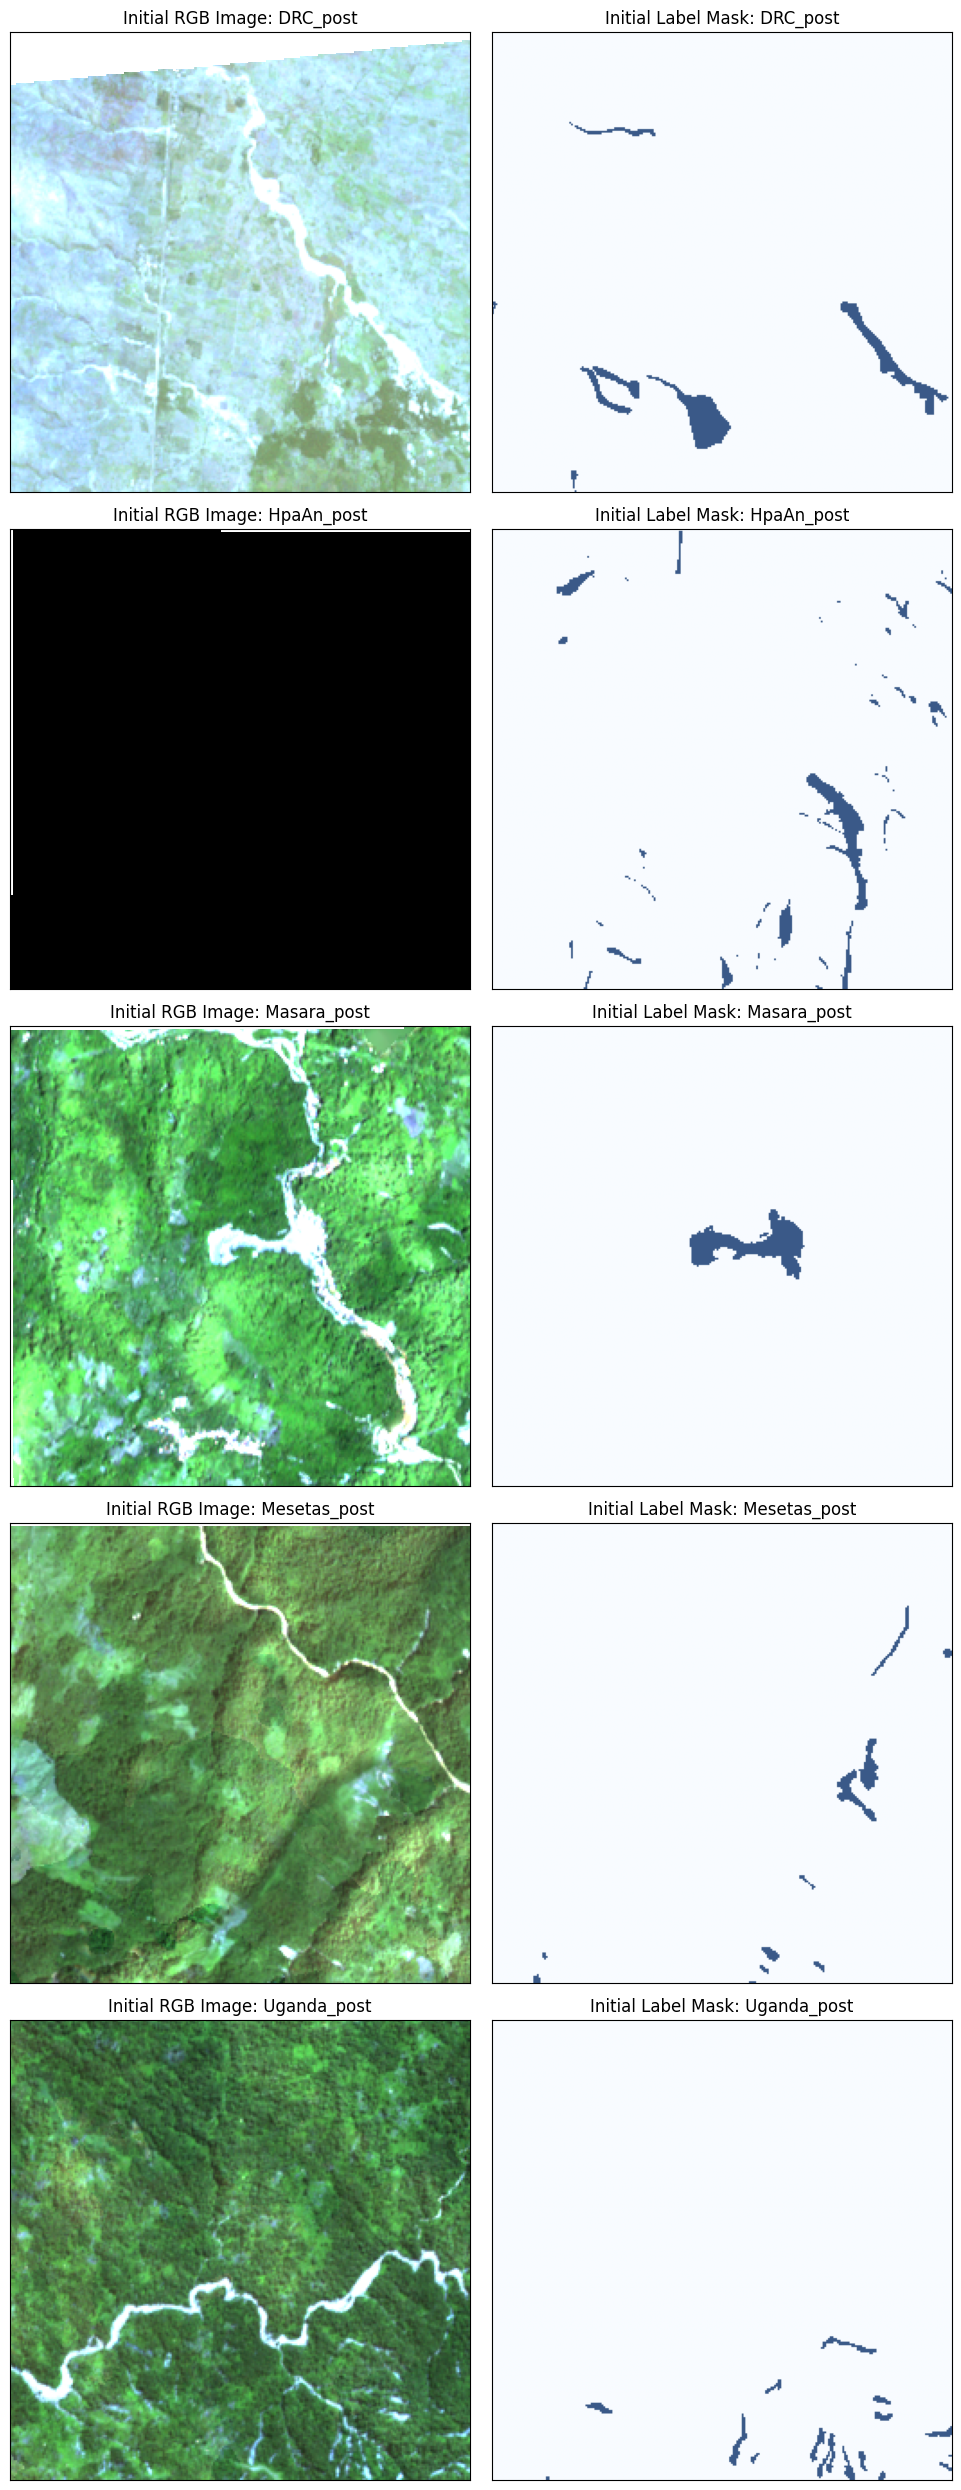

In [28]:
# Plot the first image patch of five ROIs
roi_names_to_plot = list(filtered_images1.keys())[:5]
roi_names1_to_plot = list(filtered_masks.keys())[:5]

fig, axarr = plt.subplots(len(roi_names_to_plot), 2, figsize=(10, len(roi_names_to_plot) * 5))
for i, (roi_name, roi_name1) in enumerate(zip(roi_names_to_plot, roi_names1_to_plot)):
    workimage_1 = filtered_images1[roi_name]
    workmask = filtered_masks[roi_name1]

    axarr[i, 0].imshow(workimage_1[0][:, :, :3]/1000)  # Display the first three channels as RGB
    axarr[i, 0].set_title(f"Initial RGB Image: {roi_name}")
    axarr[i, 0].set(xticks=[], yticks=[])

    axarr[i, 1].imshow(np.squeeze(workmask[0]), cmap='Blues', alpha=0.8)
    axarr[i, 1].set_title(f"Initial Label Mask: {roi_name}")
    axarr[i, 1].set(xticks=[], yticks=[])

plt.tight_layout()
plt.show()

In [29]:
#Normalize the values between -1 and 1
def normalize_patches(roi_dict, exclude_indices, nodata_value=np.nan):

    def normalize_channels(data, channels_to_normalize, nodata_value):

        normalized_data = data.copy()

        for i in range(len(normalized_data)):  # Iterate over patches
            for j in channels_to_normalize:  # Iterate over channels to normalize
                # Get the channel data
                channel_data = normalized_data[i, :, :, j]

                # Create a mask for valid data (not NoData)
                valid_mask = ~np.isnan(channel_data) if np.isnan(nodata_value) else (channel_data != nodata_value)

                # Normalize only valid data
                if np.any(valid_mask):  # Proceed if there are valid values
                    min_val = channel_data[valid_mask].min()
                    max_val = channel_data[valid_mask].max()
                    range_val = max_val - min_val

                    # Avoid division by zero
                    if range_val != 0:
                        channel_data[valid_mask] = ((channel_data[valid_mask] - min_val) / range_val)* 2 - 1
                    else:
                        channel_data[valid_mask] = 0  # Set all valid values to 0 if they are constant

                # Assign the normalized channel data back
                normalized_data[i, :, :, j] = channel_data

        return normalized_data

    # Process each ROI in the dictionary
    normalized_roi_dict = {}
    for roi_name, image_stack in roi_dict.items():
        #print(f"Normalizing patches for ROI: {roi_name}")

        total_channels = image_stack.shape[-1]  # Get the number of channels
        channels_to_normalize = [i for i in range(total_channels) if i not in exclude_indices]

        # Normalize the stack
        normalized_stack = normalize_channels(image_stack, channels_to_normalize, nodata_value)
        normalized_roi_dict[roi_name] = normalized_stack

    return normalized_roi_dict

exclude_indices = [2,3]  # Indices of channels to exclude
nodata_value = np.nan  # Specify the NoData value if applicable

# Normalize the patches for each ROI
filtered_images2 = normalize_patches(filtered_images2, exclude_indices, nodata_value)

# Verify normalization
for roi_name, patches in filtered_images2.items():
    print(f"{roi_name}: Min = {np.nanmin(patches)}, Max = {np.nanmax(patches)}")


DRC_DEM: Min = -1.0, Max = 1.0
HpaAn_DEM: Min = -1.0, Max = 1.0
Masara_DEM: Min = -1.0, Max = 1.0
Mesetas_DEM: Min = -1.0, Max = 1.0
Uganda_DEM: Min = -1.0, Max = 1.0


In [30]:
#For optical images
exclude_indices = []  # Indices of channels to exclude
nodata_value = np.nan  # Specify the NoData value if applicable

# Normalize the patches for each ROI
filtered_images1 = normalize_patches(filtered_images1, exclude_indices, nodata_value)
filtered_images3 = normalize_patches(filtered_images3, exclude_indices, nodata_value)


# Verify normalization
for roi_name, patches in filtered_images1.items():
    print(f"{roi_name}: Min = {np.nanmin(patches)}, Max = {np.nanmax(patches)}")

DRC_post: Min = -1.0, Max = 1.0
HpaAn_post: Min = -1.0, Max = 1.0
Masara_post: Min = -1.0, Max = 1.0
Mesetas_post: Min = -1.0, Max = 1.0
Uganda_post: Min = -1.0, Max = 1.0


In [31]:
def count_values_in_patches(useful_masks_patches):

    result = {}

    # Iterate through each region and count occurrences of 0 and 1
    for region, mask_array in useful_masks_patches.items():
        unique, counts = np.unique(mask_array, return_counts=True)
        count_dict = dict(zip(unique, counts))

        # Check for 0  and their counts
        count_0 = count_dict.get(0, 0)  # Default to 0 if 0 is not found
        total_pixels = mask_array.size

        # Calculate percentage of 0s
        percentage_0 = (count_0 / total_pixels) * 100 if total_pixels > 0 else 0

        result[region] = {'0_percentage': percentage_0}

    return result

In [32]:
result = count_values_in_patches(filtered_images1)
for region, counts in result.items():
    print(f"Region: {region},  0 percentage: {counts['0_percentage']:.2f}%")

Region: DRC_post,  0 percentage: 0.01%
Region: HpaAn_post,  0 percentage: 0.00%
Region: Masara_post,  0 percentage: 0.00%
Region: Mesetas_post,  0 percentage: 0.00%
Region: Uganda_post,  0 percentage: 0.00%


In [33]:
result = count_values_in_patches(filtered_images2)
for region, counts in result.items():
    print(f"Region: {region},  0 percentage: {counts['0_percentage']:.2f}%")

Region: DRC_DEM,  0 percentage: 0.55%
Region: HpaAn_DEM,  0 percentage: 0.77%
Region: Masara_DEM,  0 percentage: 0.08%
Region: Mesetas_DEM,  0 percentage: 0.38%
Region: Uganda_DEM,  0 percentage: 0.65%


Boundary NoData detected for ROI: DRC_post


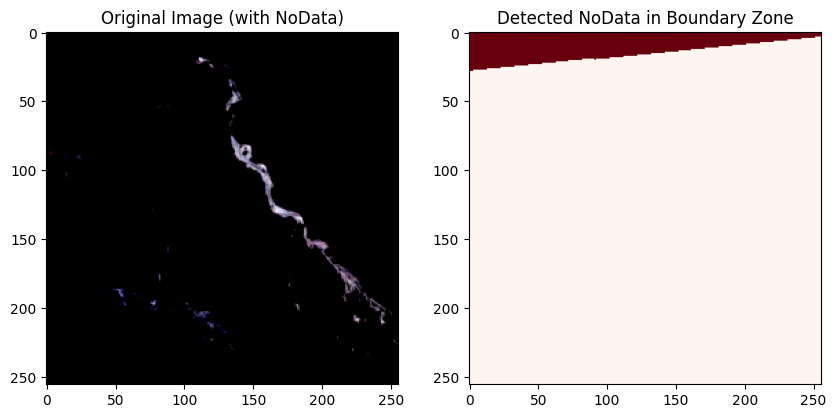

Boundary NoData detected for ROI: HpaAn_post


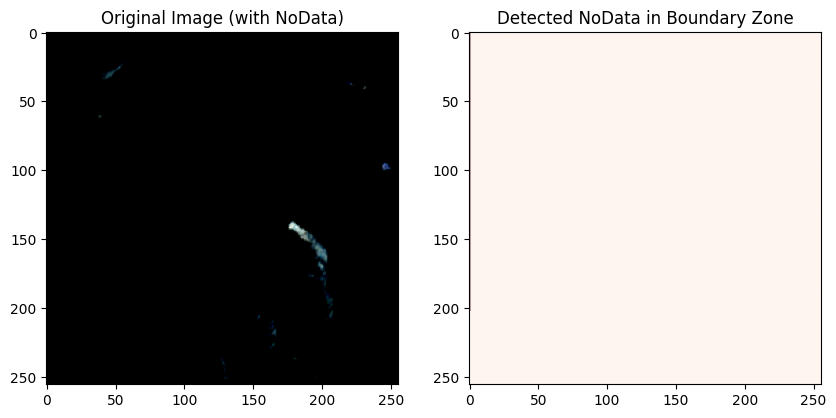

Boundary NoData detected for ROI: Masara_post


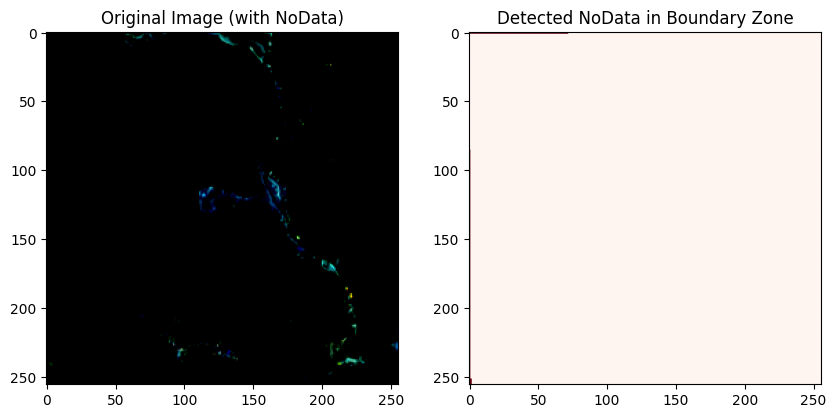

Boundary NoData detected for ROI: Mesetas_post


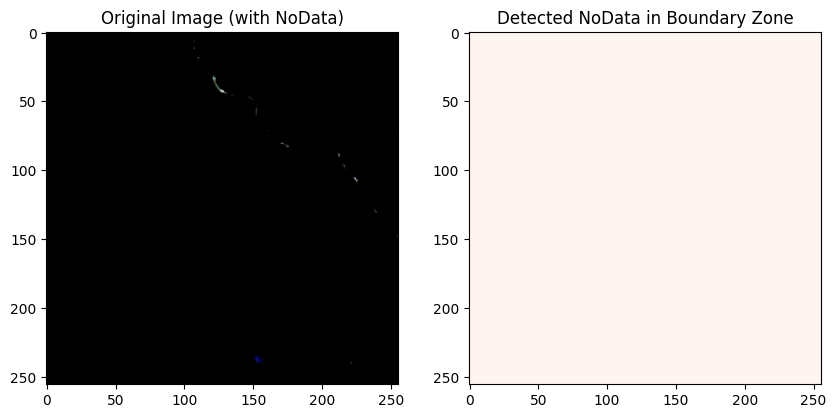

Boundary NoData detected for ROI: Uganda_post


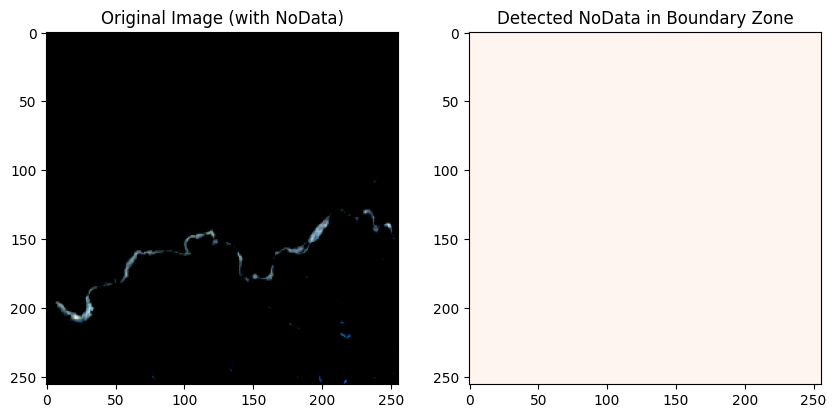

In [34]:
def detect_boundary_nodata(image, research_fraction=0.15):
    height, width, _ = image.shape
    boundary_height = int(research_fraction * height)
    boundary_width = int(research_fraction * width)

    # Detect NaN pixels in the first band
    nodata_mask = np.isnan(image[:, :, 0])  # Only check the first band for NoData

    # Define boundary zones directly using slicing
    boundary_nodata_mask = np.zeros((height, width), dtype=bool)
    boundary_nodata_mask[:boundary_height, :] |= nodata_mask[:boundary_height, :]  # Top
    boundary_nodata_mask[-boundary_height:, :] |= nodata_mask[-boundary_height:, :]  # Bottom
    boundary_nodata_mask[:, :boundary_width] |= nodata_mask[:, :boundary_width]  # Left
    boundary_nodata_mask[:, -boundary_width:] |= nodata_mask[:, -boundary_width:]  # Right

    return boundary_nodata_mask


def visualize_boundary_nodata(image, boundary_nodata_mask):

    plt.figure(figsize=(10, 5))
    # Visualize original image
    plt.subplot(1, 2, 1)
    plt.imshow(np.nan_to_num(image[:, :, :3], nan=0))  # Use RGB composite
    plt.title("Original Image (with NoData)")

    # Visualize detected NoData
    plt.subplot(1, 2, 2)
    mask_visual = np.zeros_like(image[:, :, 0])
    mask_visual[boundary_nodata_mask] = 1
    plt.imshow(mask_visual, cmap='Reds')
    plt.title("Detected NoData in Boundary Zone")
    plt.show()

# Create a dictionary to store boundary masks
boundary_masks = {}

for roi_name, patches in filtered_images1.items():
    boundary_masks[roi_name] = [
        detect_boundary_nodata(patch) for patch in patches
    ]

# Select the first image patch from the first five ROIs and visualize
selected_rois = list(filtered_images1.keys())[:5]  # First five ROIs
for roi_name in selected_rois:
    patches = filtered_images1[roi_name]
    first_patch = patches[0]  # Select the first patch

    # Get the boundary NoData mask for the first patch
    boundary_nodata_mask = boundary_masks[roi_name][0]

    print(f"Boundary NoData detected for ROI: {roi_name}")
    visualize_boundary_nodata(first_patch, boundary_nodata_mask)


In [35]:
from sklearn.impute import KNNImputer
from scipy.spatial import distance, ConvexHull
from scipy.spatial.qhull import QhullError

def knn_imputation(image, n_neighbors=5):
    """Apply KNN imputation to fill NaN values in the image."""
    # Flatten the image for KNN
    flat_image = image.reshape(-1, image.shape[-1])

    # Apply KNN imputer
    knn_imputer = KNNImputer(n_neighbors=n_neighbors)
    imputed_flat_image = knn_imputer.fit_transform(flat_image)

    # Reshape back to the original image shape
    imputed_image = imputed_flat_image.reshape(image.shape)
    return imputed_image

def calculate_threshold(original_image, alpha=1.0):
    """Calculate threshold for valid pixel values."""
    mean = np.nanmean(original_image, axis=(0, 1))  # Mean for each band
    variance = np.nanvar(original_image, axis=(0, 1))  # Variance for each band
    threshold = np.minimum(mean - alpha * np.sqrt(variance), mean + alpha * np.sqrt(variance))
    return threshold

def find_nearest_valid_pixel(image, i, j, band):
    """Find the nearest valid pixel value for a given NaN pixel."""
    valid_mask = ~np.isnan(image[:, :, band])
    valid_coords = np.column_stack(np.where(valid_mask))
    target_coords = np.array([i, j])

    if len(valid_coords) == 0:
        return 0  # Return default value if no valid pixels found

    dist = distance.cdist([target_coords], valid_coords, 'euclidean')
    nearest_valid_index = np.argmin(dist)
    nearest_valid_value = image[valid_coords[nearest_valid_index][0],
                               valid_coords[nearest_valid_index][1], band]
    return nearest_valid_value

def is_close_to_nearest_valid(value, nearest_valid_value, threshold):
    """Check if a value is close to its nearest valid neighbor."""
    return abs(value - nearest_valid_value) < threshold

def detect_boundary_nodata(image, research_fraction=0.15):
    """Detect NaN values near image boundaries."""
    height, width, _ = image.shape
    boundary_height = int(research_fraction * height)
    boundary_width = int(research_fraction * width)

    # Detect NaN pixels in the first band
    nodata_mask = np.isnan(image[:, :, 0])  # Only check the first band for NoData

    # Define boundary zones
    boundary_nodata_mask = np.zeros((height, width), dtype=bool)
    boundary_nodata_mask[:boundary_height, :] |= nodata_mask[:boundary_height, :]  # Top
    boundary_nodata_mask[-boundary_height:, :] |= nodata_mask[-boundary_height:, :]  # Bottom
    boundary_nodata_mask[:, :boundary_width] |= nodata_mask[:, :boundary_width]  # Left
    boundary_nodata_mask[:, -boundary_width:] |= nodata_mask[:, -boundary_width:]  # Right

    return boundary_nodata_mask

<ipython-input-35-e622222d23b1>:3: DeprecationWarning: Please import `QhullError` from the `scipy.spatial` namespace; the `scipy.spatial.qhull` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.spatial.qhull import QhullError


In [36]:
def replace_nodata_boundary(image, original_image, n_neighbors=5, alpha=1.0, debug=False):
    """Replace NaN values in the image using KNN imputation with boundary handling."""
    height, width, bands = image.shape

    if debug:
        print("\n=== DEBUGGING NaN VALUES ===")
        print(f"Initial NaN count: {np.isnan(image).sum()}")  # Total NaN count
        for band in range(bands):
            nan_count = np.isnan(image[:, :, band]).sum()
            print(f"Band {band}: {nan_count} NaN pixels")

    boundary_mask = detect_boundary_nodata(image)

    if debug:
        boundary_nan_count = np.isnan(image[:, :, 0][boundary_mask]).sum()
        inner_nan_count = np.isnan(image[:, :, 0][~boundary_mask]).sum()
        print(f"Boundary NaN pixels: {boundary_nan_count}")
        print(f"Inner NaN pixels: {inner_nan_count}")

    # First apply KNN imputation to the entire image
    imputed_image = knn_imputation(image, n_neighbors)

    if debug:
        print(f"\nAfter KNN imputation:")
        print(f"Total NaN remaining: {np.isnan(imputed_image).sum()}")
        for band in range(bands):
            nan_count = np.isnan(imputed_image[:, :, band]).sum()
            print(f"Band {band}: {nan_count} NaN pixels remaining")

    # Calculate threshold based on original image
    threshold = calculate_threshold(original_image, alpha)

    # Handle boundary NaN values
    for band in range(bands):
        nan_mask = np.isnan(image[:, :, band])
        band_nan_count = nan_mask.sum()

        if debug and band_nan_count > 0:
            print(f"\nProcessing Band {band} - Original NaN count: {band_nan_count}")

        for i, j in zip(*np.where(nan_mask)):
            if boundary_mask[i, j]:
                nearest_valid_value = find_nearest_valid_pixel(original_image, i, j, band)

                if debug and np.isnan(nearest_valid_value):
                    print(f"Warning: No valid neighbor found for boundary pixel ({i},{j}) in band {band}")

                if not np.isnan(nearest_valid_value):
                    imputed_image[i, j, band] = nearest_valid_value
                else:
                    imputed_image[i, j, band] = 0.0  # Default value

    if debug:
        print(f"\nAfter boundary handling:")
        print(f"Total NaN remaining: {np.isnan(imputed_image).sum()}")
        for band in range(bands):
            nan_count = np.isnan(imputed_image[:, :, band]).sum()
            print(f"Band {band}: {nan_count} NaN pixels remaining")

    # Final check to ensure no NaN values remain
    if np.isnan(imputed_image).any():
        if debug:
            print("\nFinal cleanup needed - some NaN values remain")
            print("Applying mean imputation as fallback...")

        for band in range(bands):
            band_data = imputed_image[:, :, band]
            nan_count = np.isnan(band_data).sum()

            if nan_count > 0:
                band_mean = np.nanmean(band_data)
                if debug:
                    print(f"Band {band}: Replacing {nan_count} NaN values with mean: {band_mean}")

                if np.isnan(band_mean):
                    if debug:
                        print("Warning: Entire band is NaN! Using 0 as fallback")
                    band_mean = 0.0

                band_data[np.isnan(band_data)] = band_mean
                imputed_image[:, :, band] = band_data

    if debug:
        final_nan_count = np.isnan(imputed_image).sum()
        if final_nan_count == 0:
            print("\nSUCCESS: All NaN values have been filled")
        else:
            print(f"\nWARNING: {final_nan_count} NaN values remain after all processing")

    return imputed_image

In [37]:
# Or process all patches with debugging
def process_image_patches(roi_dict, knn_neighbors=5, alpha=1.0, debug=False):
    imputed_rois = {}
    for roi_name, image_stack in roi_dict.items():
        print(f"\nProcessing ROI: {roi_name} with {image_stack.shape[0]} patches")
        imputed_patches = []

        for i in range(image_stack.shape[0]):
            if debug:
                print(f"\nProcessing patch {i+1}/{image_stack.shape[0]}")

            original_image = image_stack[i]
            imputed_image = replace_nodata_boundary(
                np.copy(original_image),
                original_image,
                n_neighbors=knn_neighbors,
                alpha=alpha,
                debug=debug
            )
            imputed_patches.append(imputed_image)

        imputed_rois[roi_name] = np.array(imputed_patches)

    return imputed_rois

In [38]:
# Run with debugging enabled
filtered_images1 = process_image_patches(filtered_images1, debug=True)
filtered_images3 = process_image_patches(filtered_images3, debug=True)

Streaming output truncated to the last 5000 lines.
Band 2: 0 NaN pixels
Band 3: 0 NaN pixels
Band 4: 0 NaN pixels
Band 5: 0 NaN pixels
Boundary NaN pixels: 0
Inner NaN pixels: 0

After KNN imputation:
Total NaN remaining: 0
Band 0: 0 NaN pixels remaining
Band 1: 0 NaN pixels remaining
Band 2: 0 NaN pixels remaining
Band 3: 0 NaN pixels remaining
Band 4: 0 NaN pixels remaining
Band 5: 0 NaN pixels remaining

After boundary handling:
Total NaN remaining: 0
Band 0: 0 NaN pixels remaining
Band 1: 0 NaN pixels remaining
Band 2: 0 NaN pixels remaining
Band 3: 0 NaN pixels remaining
Band 4: 0 NaN pixels remaining
Band 5: 0 NaN pixels remaining

SUCCESS: All NaN values have been filled

Processing patch 3/39

=== DEBUGGING NaN VALUES ===
Initial NaN count: 0
Band 0: 0 NaN pixels
Band 1: 0 NaN pixels
Band 2: 0 NaN pixels
Band 3: 0 NaN pixels
Band 4: 0 NaN pixels
Band 5: 0 NaN pixels
Boundary NaN pixels: 0
Inner NaN pixels: 0

After KNN imputation:
Total NaN remaining: 0
Band 0: 0 NaN pixels rem

In [39]:
filtered_images2 = process_image_patches(filtered_images2)


Processing ROI: DRC_DEM with 39 patches

Processing ROI: HpaAn_DEM with 1 patches

Processing ROI: Masara_DEM with 1 patches

Processing ROI: Mesetas_DEM with 3 patches

Processing ROI: Uganda_DEM with 27 patches


In [40]:
# Find NaN values in the array
def find_nodata(image_dict):
    nan_indices_dict = {}  # Dictionary to store indices of NaN values for each ROI

    for roi_name, image_array in image_dict.items():

        # Find indices of NaN values
        nan_indices = np.where(np.isnan(image_array))

        # Store the  NaN indices
        nan_indices_dict[roi_name] = nan_indices

    return nan_indices_dict


nan_indices1 = find_nodata(filtered_images1)
nan_indices2 = find_nodata(filtered_images2)
nan_indices3 = find_nodata(filtered_images3)

# Print NaN indices for each ROI
for roi_name, nan_indices in nan_indices1.items():
    print(f"ROI: {roi_name}")
    print("Indices of NaN values:", nan_indices)

for roi_name, nan_indices in nan_indices2.items():
    print(f"ROI: {roi_name}")
    print("Indices of NaN values:", nan_indices)

ROI: DRC_post
Indices of NaN values: (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
ROI: HpaAn_post
Indices of NaN values: (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
ROI: Masara_post
Indices of NaN values: (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
ROI: Mesetas_post
Indices of NaN values: (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
ROI: Uganda_post
Indices of NaN values: (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
ROI: DRC_DEM
Indices of NaN values: (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
ROI: HpaAn_DEM
Indices of NaN values: (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
ROI: Masara_DEM
Indices of NaN values: (array([], 

In [ ]:
def replace_nodata_with_zero(image_dict):

    updated_dict = {}
    for roi_name, image_array in image_dict.items():
        # Replace NaN values with 0 using np.nan_to_num
        updated_array = np.nan_to_num(image_array, nan= 0.0)
        updated_dict[roi_name] = updated_array
    return updated_dict

In [ ]:
# Apply the function to your image dictionaries
filtered_images1 = replace_nodata_with_zero(filtered_images1)
filtered_images3 = replace_nodata_with_zero(filtered_images3)

In [ ]:
filtered_images2 = replace_nodata_with_zero(filtered_images2)

In [41]:
# Find NaN values in the array
def find_nodata(image_dict):
    nan_indices_dict = {}  # Dictionary to store indices of NaN values for each ROI

    for roi_name, image_array in image_dict.items():

        # Find indices of NaN values
        nan_indices = np.where(np.isnan(image_array))

        # Store the  NaN indices
        nan_indices_dict[roi_name] = nan_indices

    return nan_indices_dict


nan_indices1 = find_nodata(filtered_images1)
nan_indices2 = find_nodata(filtered_images2)
nan_indices3 = find_nodata(filtered_images3)

# Print NaN indices for each ROI
for roi_name, nan_indices in nan_indices1.items():
    print(f"ROI: {roi_name}")
    print("Indices of NaN values:", nan_indices)

for roi_name, nan_indices in nan_indices2.items():
    print(f"ROI: {roi_name}")
    print("Indices of NaN values:", nan_indices)

ROI: DRC_post
Indices of NaN values: (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
ROI: HpaAn_post
Indices of NaN values: (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
ROI: Masara_post
Indices of NaN values: (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
ROI: Mesetas_post
Indices of NaN values: (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
ROI: Uganda_post
Indices of NaN values: (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
ROI: DRC_DEM
Indices of NaN values: (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
ROI: HpaAn_DEM
Indices of NaN values: (array([], dtype=int64), array([], dtype=int64), array([], dtype=int64), array([], dtype=int64))
ROI: Masara_DEM
Indices of NaN values: (array([], 

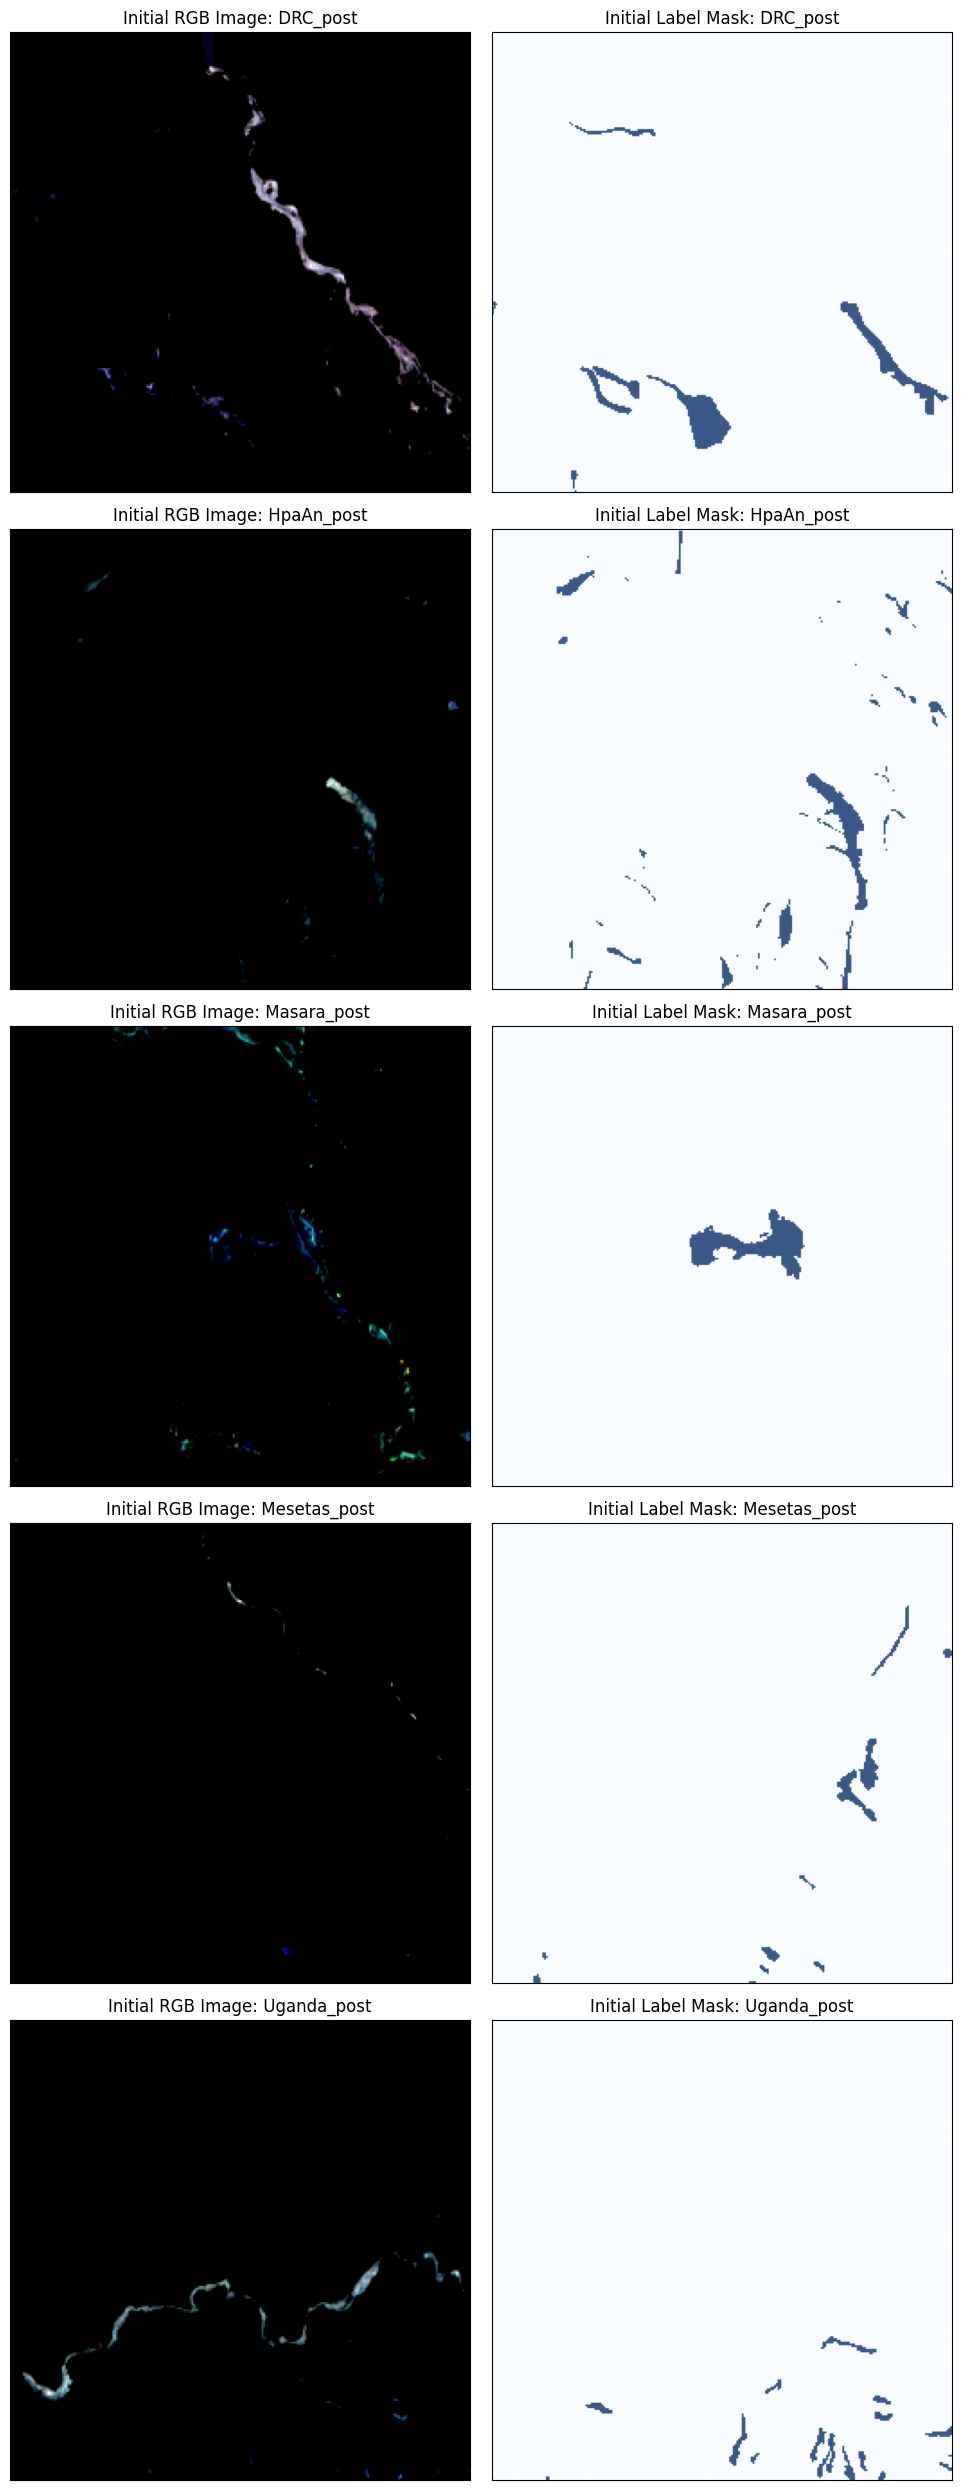

In [42]:
# Plot the first image patch of five ROIs
roi_names_to_plot = list(filtered_images1.keys())[:5]
roi_names1_to_plot = list(filtered_masks.keys())[:5]

fig, axarr = plt.subplots(len(roi_names_to_plot), 2, figsize=(10, len(roi_names_to_plot) * 5))
for i, (roi_name, roi_name1) in enumerate(zip(roi_names_to_plot, roi_names1_to_plot)):
    workimage_1 = filtered_images1[roi_name]
    workmask = filtered_masks[roi_name1]

    axarr[i, 0].imshow(workimage_1[0][:, :, :3])  # Display the first three channels as RGB
    axarr[i, 0].set_title(f"Initial RGB Image: {roi_name}")
    axarr[i, 0].set(xticks=[], yticks=[])

    axarr[i, 1].imshow(np.squeeze(workmask[0]), cmap='Blues', alpha=0.8)
    axarr[i, 1].set_title(f"Initial Label Mask: {roi_name}")
    axarr[i, 1].set(xticks=[], yticks=[])

plt.tight_layout()
plt.show()

In [43]:
# Function to stack ROIs with the same prefix
def stack_rois_by_prefix(image_dict):
    stacked_data = {}
    for roi_name, roi_array in image_dict.items():
        prefix = roi_name.split('_')[0]  # Extract prefix (e.g., "Dominica" from "Dominica_1")
        if prefix not in stacked_data:
            stacked_data[prefix] = roi_array
        else:
            stacked_data[prefix] = np.concatenate([stacked_data[prefix], roi_array], axis=0)
    return stacked_data

# Function to filter ROIs by sample count
def filter_rois_by_sample_count(image_dict, max_samples=300):
    return {roi_name: roi_array for roi_name, roi_array in image_dict.items() if roi_array.shape[0] < max_samples}

# Stack ROIs with the same prefix
stacked_post_optical_image = stack_rois_by_prefix(filtered_images1)
stacked_pre_optical_image = stack_rois_by_prefix(filtered_images3)
stacked_topographic_image = stack_rois_by_prefix(filtered_images2)
stacked_masks = stack_rois_by_prefix(filtered_masks)
stacked_changemasks = stack_rois_by_prefix(filtered_changemasks)

# Filter ROIs with fewer than 300 images
filtered_optical_image = filter_rois_by_sample_count(stacked_post_optical_image, max_samples=300)
filtered_topographic_image = filter_rois_by_sample_count(stacked_topographic_image, max_samples=300)

# Display results
print("stacked Optical ROIs:")
for key, val in stacked_post_optical_image.items():
    print(f"  {key}: {val.shape}")
print(f"Filtered Optical ROIs: {list(filtered_optical_image.keys())}")
print(f"Filtered Topographic ROIs: {list(filtered_topographic_image.keys())}")


stacked Optical ROIs:
  DRC: (39, 256, 256, 6)
  HpaAn: (1, 256, 256, 6)
  Masara: (1, 256, 256, 6)
  Mesetas: (3, 256, 256, 6)
  Uganda: (27, 256, 256, 6)
Filtered Optical ROIs: ['DRC', 'HpaAn', 'Masara', 'Mesetas', 'Uganda']
Filtered Topographic ROIs: ['DRC', 'HpaAn', 'Masara', 'Mesetas', 'Uganda']


In [44]:
total_patches1 = sum(val.shape[0] for val in stacked_post_optical_image.values())
total_patches2 = sum(val.shape[0] for val in stacked_topographic_image.values())
total_patches3 = sum(val.shape[0] for val in stacked_pre_optical_image.values())
total_patches4 = sum(val.shape[0] for val in stacked_masks.values())

print("Total patches in image_list1:", total_patches1)
print("Total patches in image_list2:", total_patches2)
print("Total patches in image_list3:", total_patches3)
print("Total patches in image_list3:", total_patches4)

Total patches in image_list1: 71
Total patches in image_list2: 71
Total patches in image_list3: 71
Total patches in image_list3: 71


In [ ]:
del filtered_images1, filtered_images2, filtered_images3

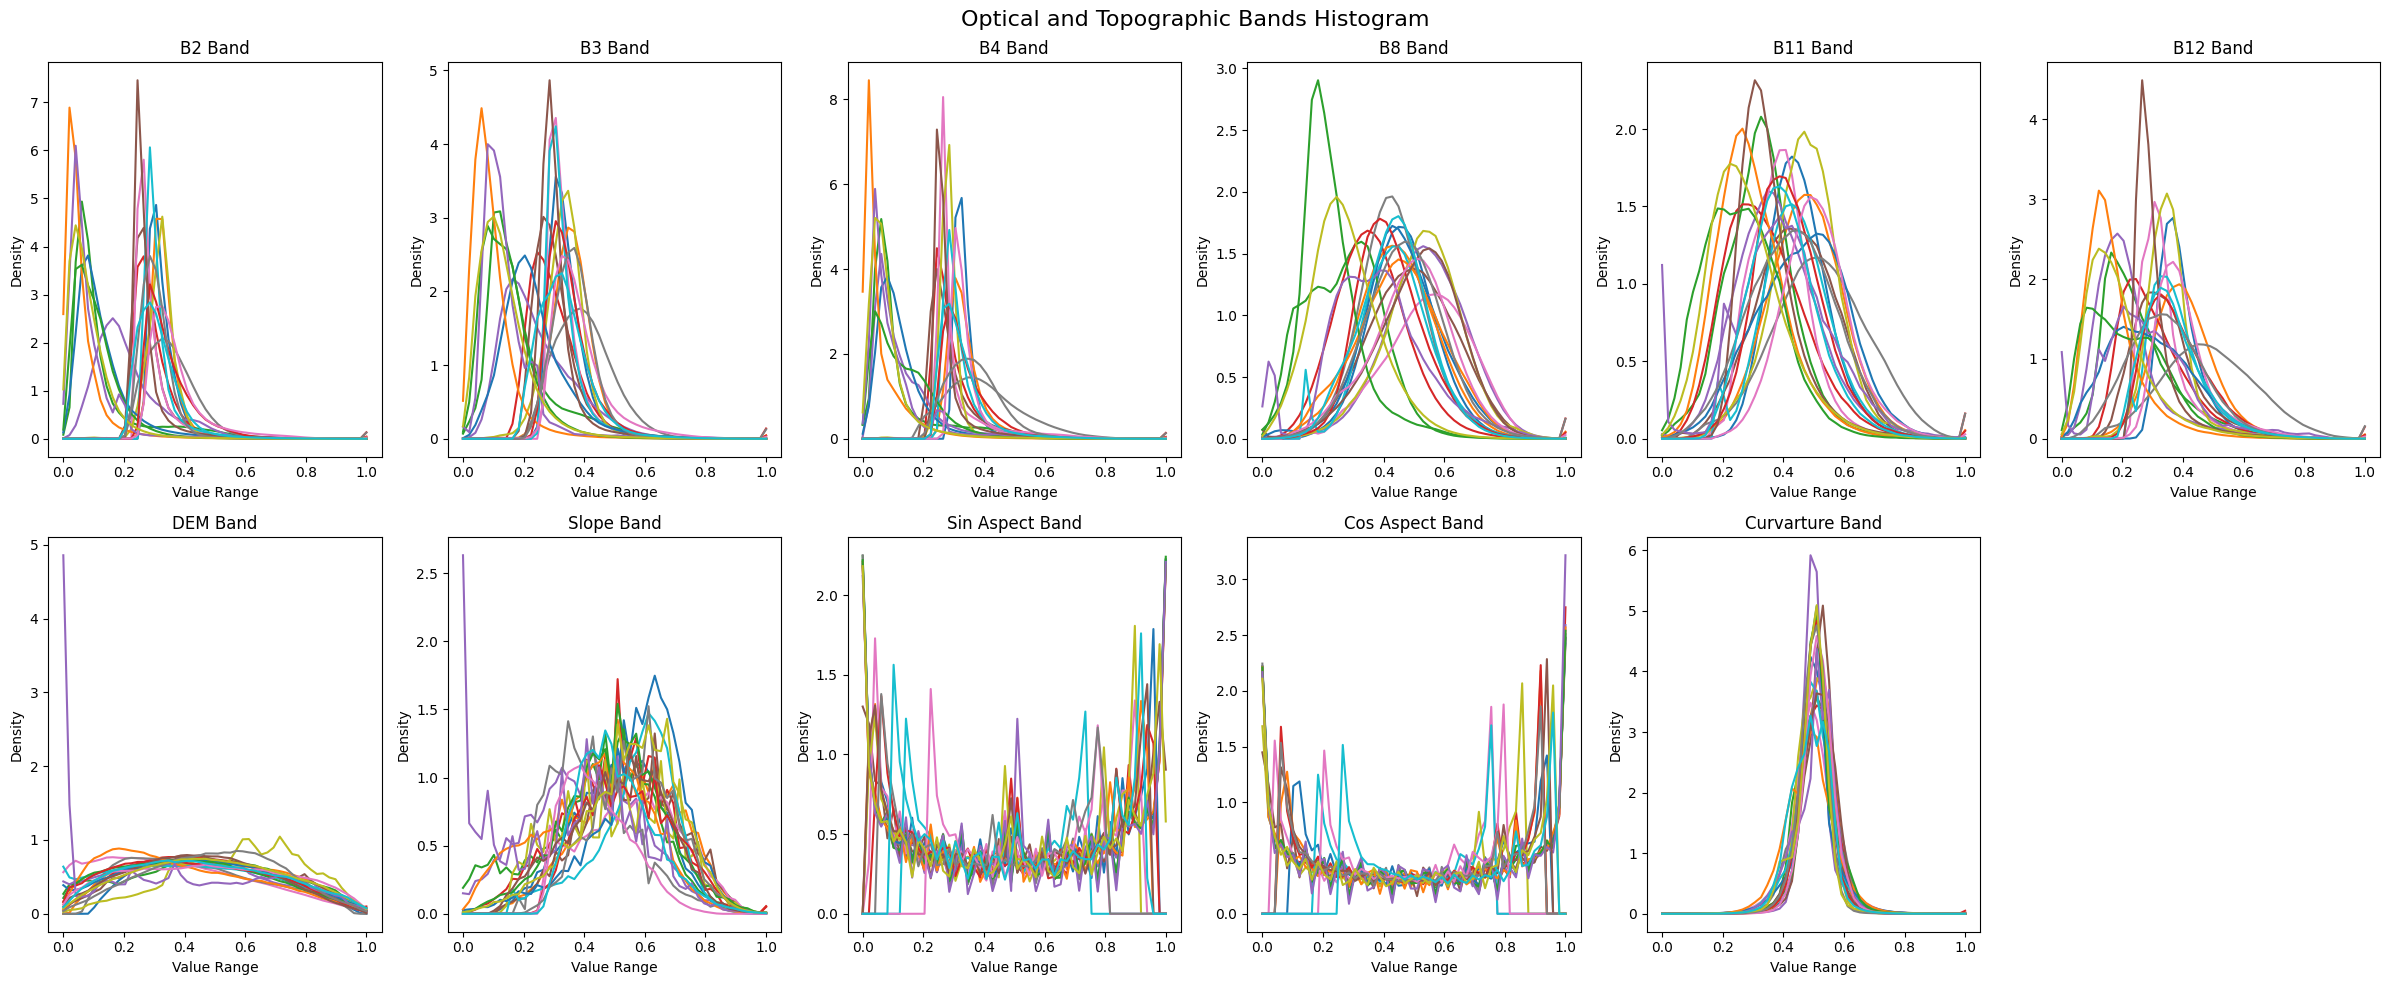

In [ ]:
# Function to compute histograms for each band
def compute_histograms(roi_data, bins=50):
    histograms = {}
    for roi_name, roi_array in roi_data.items():
        bands_hist = []
        for band in range(roi_array.shape[-1]):
            band_data = roi_array[..., band].flatten()
            hist, _ = np.histogram(band_data, bins=bins, density=True)
            bands_hist.append(hist)
        histograms[roi_name] = np.array(bands_hist)
    return histograms

# Compute histograms for filtered optical and topographic data
optical_histograms = compute_histograms(filtered_optical_image)
topographic_histograms = compute_histograms(filtered_topographic_image)

# Function to plot histograms
def plot_histograms(optical_histograms, topographic_histograms, optical_labels, topographic_labels):
    num_optical_bands = len(optical_labels)
    num_topographic_bands = len(topographic_labels)
    rois = list(optical_histograms.keys())
    rois1 = list(topographic_histograms.keys())

    # Define the grid layout: 2 rows and 6 columns
    total_bands = num_optical_bands + num_topographic_bands
    rows = 2
    cols = 6  # Maximum of 6 columns per row
    fig, axes = plt.subplots(rows, cols, figsize=(24, 10))

    # Flatten axes for easy indexing
    axes = axes.flatten()

    # Plot optical bands
    for i in range(num_optical_bands):
        ax = axes[i]
        for roi_name in rois:
            x = np.linspace(0, 1, optical_histograms[roi_name][i].shape[0])
            ax.plot(x, optical_histograms[roi_name][i], label=roi_name)
        ax.set_title(f"{optical_labels[i]} Band")
        ax.set_xlabel("Value Range")
        ax.set_ylabel("Density")
        #ax.legend(loc="upper right", fontsize=8)

    # Plot topographic bands
    for i in range(num_topographic_bands):
        ax = axes[num_optical_bands + i]
        for roi_name in rois1:
            x = np.linspace(0, 1, topographic_histograms[roi_name][i].shape[0])
            ax.plot(x, topographic_histograms[roi_name][i], label=roi_name)
        ax.set_title(f"{topographic_labels[i]} Band")
        ax.set_xlabel("Value Range")
        ax.set_ylabel("Density")
        #ax.legend(loc="upper right", fontsize=8)

    # Turn off any unused subplots
    for j in range(total_bands, rows * cols):
        axes[j].axis("off")
    # Add legend to the last plot of topographic bands
    #ax.legend(loc='best', bbox_to_anchor=(1.15, 1), title="ROIs")
    # Add a global title and adjust layout
    plt.suptitle("Optical and Topographic Bands Histogram", fontsize=16)
    plt.tight_layout()  # Adjust layout to fit the title
    plt.show()

# Band labels
optical_band_labels = ["B2", "B3", "B4", "B8", "B11", "B12"]
topographic_band_labels = ["DEM", "Slope", "Sin Aspect", "Cos Aspect", "Curvarture"]

# Plot the histograms
plot_histograms(
    optical_histograms,
    topographic_histograms,
    optical_band_labels,
    topographic_band_labels
)

In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

(20, 300)


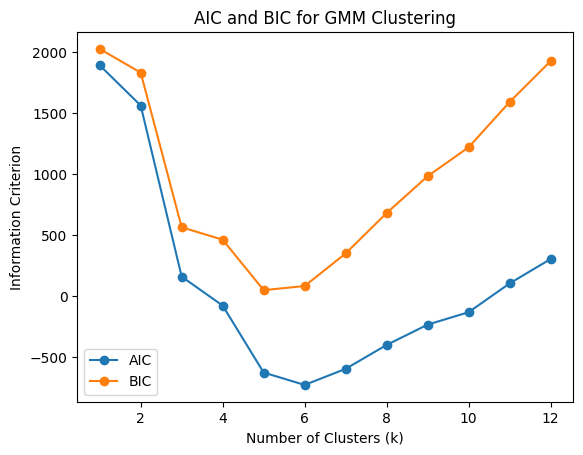

In [ ]:
# Flatten histograms into feature vectors
features1 = []
roi_names = []
for roi_name, histograms in optical_histograms.items():
    roi_names.append(roi_name)
    features1.append(histograms.flatten())  # Flatten into a single vector
features1 = np.array(features1)

features2 = []
roi_names = []
for roi_name, histograms in topographic_histograms.items():
    roi_names.append(roi_name)
    features2.append(histograms.flatten())  # Flatten into a single vector
features2 = np.array(features2)

features = np.add(0.5*features1, 0.5*features2)
print(features.shape)

# Standardize features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Dimensionality reduction with PCA (optional)
pca = PCA(n_components=15)  # Reduce to 10 dimensions
features_pca = pca.fit_transform(features_scaled)

# Find optimum number of clusters using AIC or BIC
aics = [] # Akaike Information Criterion
bics = [] # Bayesian Information Criterion
for k in range(1, 13):
    gmm = GaussianMixture(n_components=k, random_state=42) # Re-initialize GMM for each k
    gmm.fit(features_pca)
    aics.append(gmm.aic(features_pca))
    bics.append(gmm.bic(features_pca))

# Plot AIC and BIC values to find the elbow point
plt.plot(range(1, 13), aics, marker='o', label='AIC')
plt.plot(range(1, 13), bics, marker='o', label='BIC')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Information Criterion')
plt.title('AIC and BIC for GMM Clustering')
plt.legend()
plt.show()

In [ ]:
# Clustering with GMM
gmm = GaussianMixture(n_components=5, random_state=42)
cluster_labels = gmm.fit_predict(features_pca)

# Map each ROI to its cluster
roi_clusters = {roi_names[i]: cluster_labels[i] for i in range(len(roi_names))}

# Group ROIs by cluster
from collections import defaultdict
cluster_groups = defaultdict(list)
for roi, cluster in roi_clusters.items():
    cluster_groups[cluster].append(roi)

# Display ROIs for each cluster
for cluster_id, rois in cluster_groups.items():
    print(f"Cluster {cluster_id}: {', '.join(rois)}")

Cluster 2: Agatha, Luding, Palu, Papua
Cluster 4: Burundi, Honduras, Itogon, Japan, Lanao, Otis, Rwanda, Zimbabwe
Cluster 1: Butangbunasi, Maerkang, Nepal, San
Cluster 3: India, Marche, Pacific
Cluster 0: Kenya


In [ ]:
labels_1 = [
    2, 2, 1, 4, 3, 4, 4, 0, 2, 2, 1, 3, 1, 2, 3, 4, 2, 2, 1, 2
]

In [ ]:
labels_2 = [
    3, 0, 2, 3, 1, 4, 2, 0, 4, 2, 2, 3, 1, 3, 3, 4, 4, 0, 3, 0
]

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

# Assuming `X` is your histogram feature matrix (shape: 20x300)

# Compute Silhouette Scores
silhouette_1 = silhouette_score(features, labels_1)
silhouette_2 = silhouette_score(features, labels_2)

# Compute Davies-Bouldin Index
dbi_1 = davies_bouldin_score(features, labels_1)
dbi_2 = davies_bouldin_score(features, labels_2)

# Compute Adjusted Rand Index (to compare the two clustering results)
ari = adjusted_rand_score(labels_1, labels_2)

# Print Results
print(f"Silhouette Score for Clustering 1: {silhouette_1}")
print(f"Silhouette Score for Clustering 2: {silhouette_2}")
print(f"Davies-Bouldin Index for Clustering 1: {dbi_1}")
print(f"Davies-Bouldin Index for Clustering 2: {dbi_2}")
print(f"Adjusted Rand Index between Clustering 1 and Clustering 2: {ari}")


Silhouette Score for Clustering 1: 0.06146071731355882
Silhouette Score for Clustering 2: -0.14139328179347166
Davies-Bouldin Index for Clustering 1: 1.4636815714290408
Davies-Bouldin Index for Clustering 2: 2.8538364191051486
Adjusted Rand Index between Clustering 1 and Clustering 2: 0.009909448146249786


In [ ]:
del filtered_optical_image, filtered_topographic_image

In [45]:
# Define groups with ROI names
roi_groups = {
    "Group 0": ["DRC"],
    "Group 2": ["HpaAn"],
    "Group 3": ["Masara"],
    "Group 4": ["Mesetas"],
    "Group 5": ["Uganda"]}

# Function to get grouped ROIs
def get_grouped_rois(image_dict, groups):
    grouped_data = {}
    for group_name, roi_names in groups.items():
        group_arrays = [image_dict[roi_name] for roi_name in roi_names if roi_name in image_dict]
        if group_arrays:  # Check if there are valid ROIs in this group
            grouped_data[group_name] = np.concatenate(group_arrays, axis=0)
    return grouped_data

In [46]:
# Get grouped ROIs for optical and topographic data
grouped_post_optical = get_grouped_rois(stacked_post_optical_image, roi_groups)
grouped_pre_optical = get_grouped_rois(stacked_pre_optical_image, roi_groups)
grouped_masks = get_grouped_rois(stacked_masks, roi_groups)
grouped_changemasks = get_grouped_rois(stacked_changemasks, roi_groups)

In [47]:
grouped_topographic = get_grouped_rois(stacked_topographic_image, roi_groups)
# Display results
print(f"Optical Group Histograms: {list(grouped_post_optical.keys())}")
print(f"Topographic Group Histograms: {list(grouped_topographic.keys())}")
print("stacked Optical ROIs:")
for key, val in grouped_post_optical.items():
    print(f"  {key}: {val.shape}")

for key, val in grouped_masks.items():
    print(f"  {key}: {val.shape}")

Optical Group Histograms: ['Group 0', 'Group 2', 'Group 3', 'Group 4', 'Group 5']
Topographic Group Histograms: ['Group 0', 'Group 2', 'Group 3', 'Group 4', 'Group 5']
stacked Optical ROIs:
  Group 0: (39, 256, 256, 6)
  Group 2: (1, 256, 256, 6)
  Group 3: (1, 256, 256, 6)
  Group 4: (3, 256, 256, 6)
  Group 5: (27, 256, 256, 6)
  Group 0: (39, 256, 256, 1)
  Group 2: (1, 256, 256, 1)
  Group 3: (1, 256, 256, 1)
  Group 4: (3, 256, 256, 1)
  Group 5: (27, 256, 256, 1)


In [48]:
total_patches1 = sum(val.shape[0] for val in grouped_post_optical.values())
total_patches2 = sum(val.shape[0] for val in grouped_topographic.values())
total_patches3 = sum(val.shape[0] for val in grouped_pre_optical.values())
total_patches4 = sum(val.shape[0] for val in grouped_masks.values())


print("Total patches in image_list1:", total_patches1)
print("Total patches in image_list2:", total_patches2)
print("Total patches in image_list3:", total_patches3)
print("Total patches in image_list3:", total_patches4)

Total patches in image_list1: 71
Total patches in image_list2: 71
Total patches in image_list3: 71
Total patches in image_list3: 71


In [49]:
del stacked_post_optical_image, stacked_pre_optical_image, stacked_topographic_image

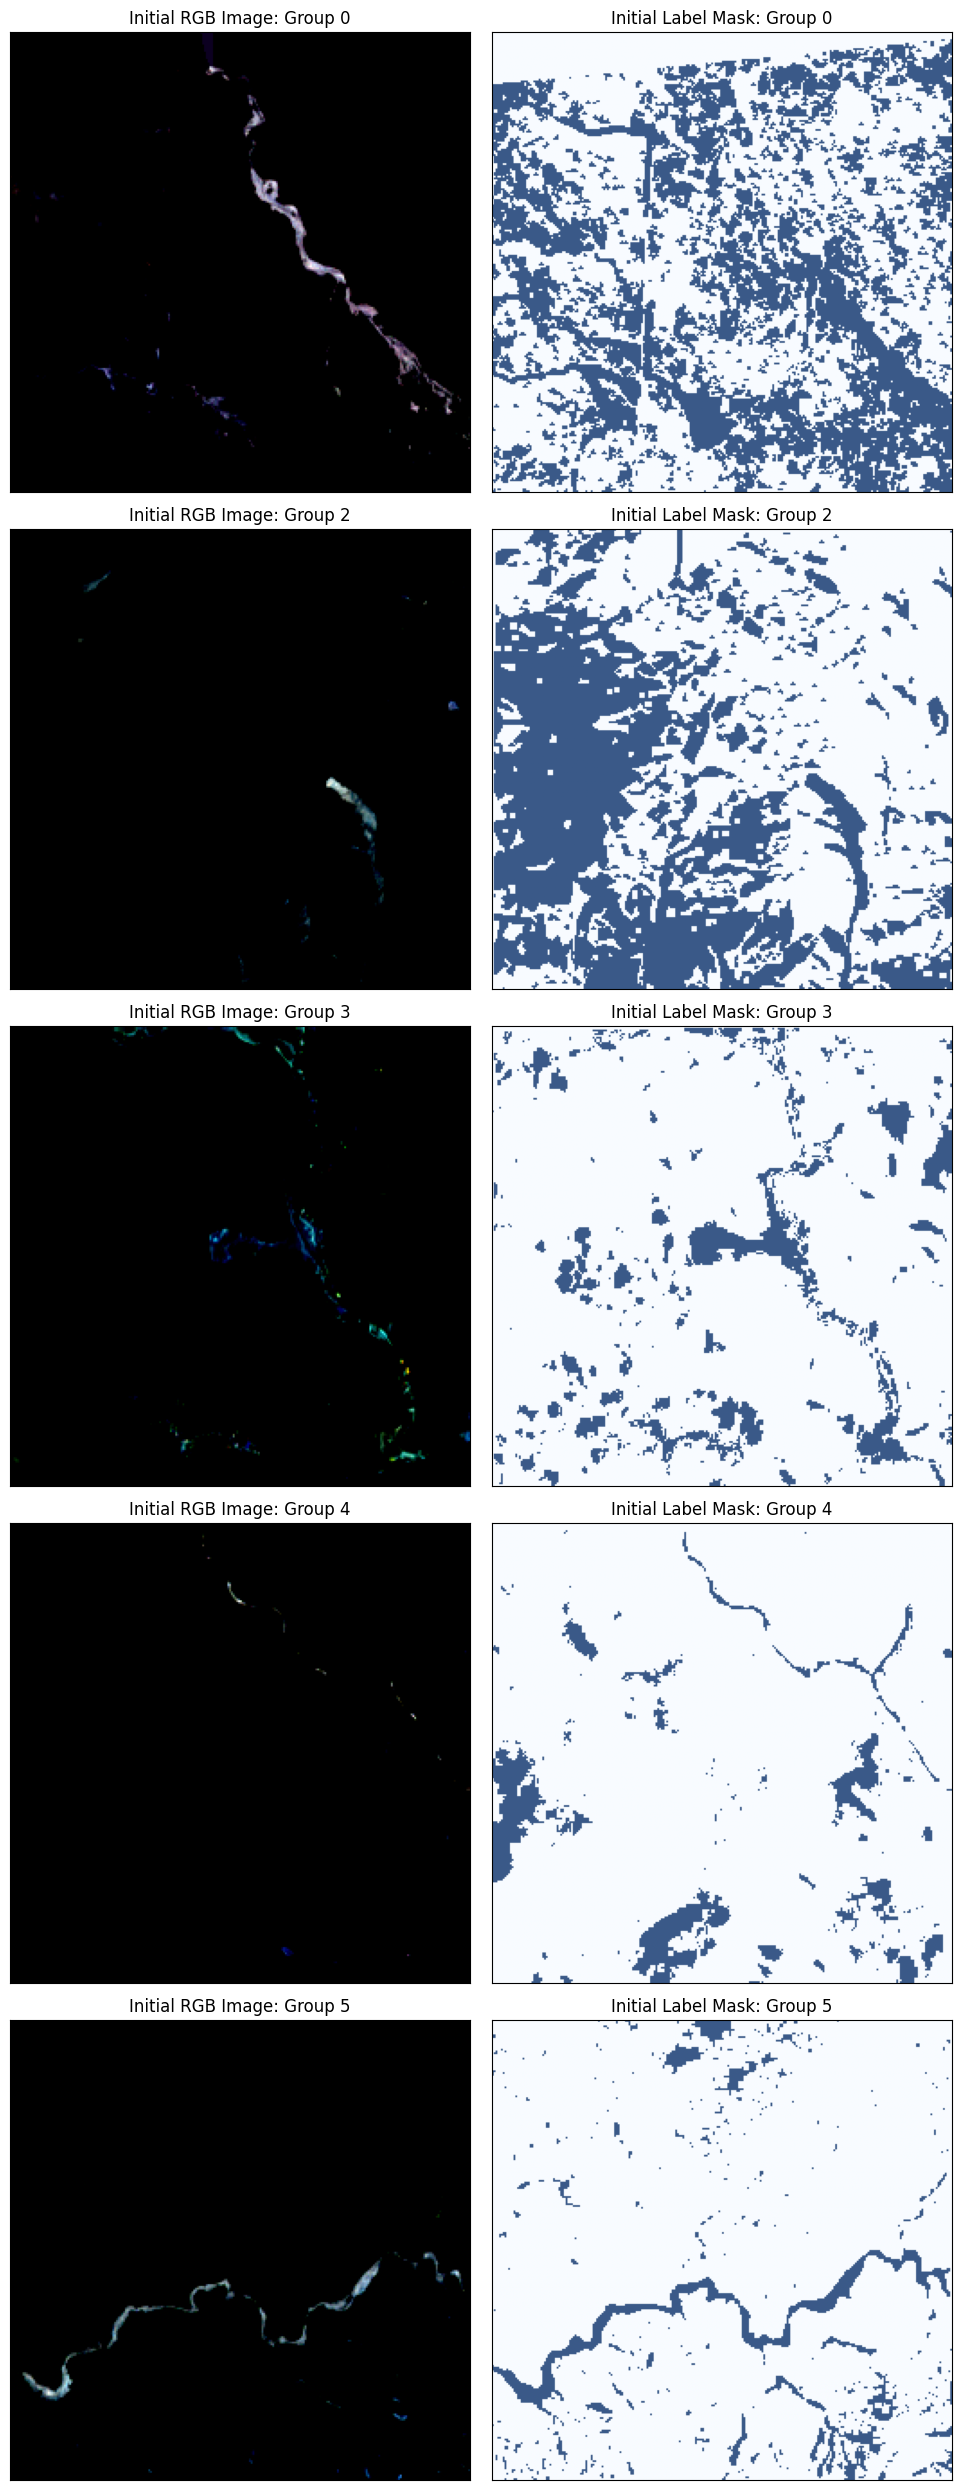

In [50]:
# Plot the first image patch of five ROIs
roi_names_to_plot = list(grouped_post_optical.keys())[:5]
roi_names1_to_plot = list(grouped_changemasks.keys())[:5]

fig, axarr = plt.subplots(len(roi_names_to_plot), 2, figsize=(10, len(roi_names_to_plot) * 5))
for i, (roi_name, roi_name1) in enumerate(zip(roi_names_to_plot, roi_names1_to_plot)):
    workimage_1 = grouped_post_optical[roi_name]
    workmask = grouped_changemasks[roi_name1]

    axarr[i, 0].imshow(workimage_1[0][:, :, :3])  # Display the first three channels as RGB
    axarr[i, 0].set_title(f"Initial RGB Image: {roi_name}")
    axarr[i, 0].set(xticks=[], yticks=[])

    axarr[i, 1].imshow(np.squeeze(workmask[0]), cmap='Blues', alpha=0.8)
    axarr[i, 1].set_title(f"Initial Label Mask: {roi_name}")
    axarr[i, 1].set(xticks=[], yticks=[])

plt.tight_layout()
plt.show()

In [ ]:
import pickle

# Define file paths
output_path = "/content/Dictionnary/"  # Replace with your desired directory
grouped_post_optical_file = output_path + "grouped_post_optical.pkl"
grouped_pre_optical_file = output_path + "grouped_pre_optical.pkl"
grouped_topographic_file = output_path + "grouped_topographic.pkl"
grouped_masks_file = output_path + "grouped_masks.pkl"
grouped_changemasks_file = output_path + "grouped_changemasks.pkl"


# Save the dictionaries
with open(grouped_post_optical_file, "wb") as f:
    pickle.dump(grouped_post_optical, f)

with open(grouped_pre_optical_file, "wb") as f:
    pickle.dump(grouped_pre_optical, f)

with open(grouped_topographic_file, "wb") as f:
    pickle.dump(grouped_topographic, f)

with open(grouped_masks_file, "wb") as f:
    pickle.dump(grouped_masks, f)

with open(grouped_changemasks_file, "wb") as f:
    pickle.dump(grouped_changemasks, f)
print("Dictionaries saved successfully!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/Dictionnary/grouped_post_optical.pkl'

In [51]:
import pickle

# Define file paths
output_path = "/content/drive/MyDrive/landslide/Data/Arrays/Dict/"  # Replace with your desired directory
grouped_post_optical_file = output_path + "Test_grouped_post_optical.pkl"

# Save the dictionaries
with open(grouped_post_optical_file, "wb") as f:
    pickle.dump(grouped_post_optical, f)

print("Dictionaries saved successfully!")

Dictionaries saved successfully!


In [52]:

# Define file paths
output_path = "/content/drive/MyDrive/landslide/Data/Arrays/Dict/"  # Replace with your desired directory
grouped_pre_optical_file = output_path + "Test_grouped_pre_optical.pkl"

with open(grouped_pre_optical_file, "wb") as f:
    pickle.dump(grouped_pre_optical, f)

print("Dictionaries saved successfully!")

Dictionaries saved successfully!


In [53]:

# Define file paths
output_path = "/content/drive/MyDrive/landslide/Data/Arrays/Dict/"  # Replace with your desired directory
grouped_topographic_file = output_path + "Test_grouped_topographic.pkl"

with open(grouped_topographic_file, "wb") as f:
    pickle.dump(grouped_topographic, f)

print("Dictionaries saved successfully!")

Dictionaries saved successfully!


In [54]:
# Define file paths
output_path = "/content/drive/MyDrive/landslide/Data/Arrays/Dict/"  # Replace with your desired directory
grouped_masks_file = output_path + "Test_grouped_masks.pkl"

with open(grouped_masks_file, "wb") as f:
    pickle.dump(grouped_masks, f)
print("Dictionaries saved successfully!")

Dictionaries saved successfully!


In [55]:
# Define file paths
output_path = "/content/drive/MyDrive/landslide/Data/Arrays/Dict/"  # Replace with your desired directory
grouped_changemasks_file = output_path + "Test_grouped_changemasks.pkl"

with open(grouped_changemasks_file, "wb") as f:
    pickle.dump(grouped_changemasks, f)
print("Dictionaries saved successfully!")

Dictionaries saved successfully!
